In [1]:
# import os

# os.environ["TQDM_DISABLE"] = "True"
# os.environ["TQDM_MININTERVAL"] = "10"

# TODO: install rtree

Note on inputs:
LC_cells_radii.csv is output from Anna Grim's 3d gaussian fits to soma images.
LC Morphology Summary.csv is axonal projection metrics from Mathew Summers.



In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
# import tree_comparison.tree_compare as tc
# from joblib import Memory
from itertools import combinations
import pandas as pd
import numpy as np
# from utils import *
import utils as u

import neuron_morphology.vis.morphovis as mv 
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
morphos, soma_df = u.load_all()

## Soma info

In [3]:
len(soma_df)

114

In [4]:
soma_df = soma_df.query("x>10000 and y<5500")
soma_df.shape

(104, 10)

(10011.240725, 11043.651775, 3690.5139249999997, 5293.450975)

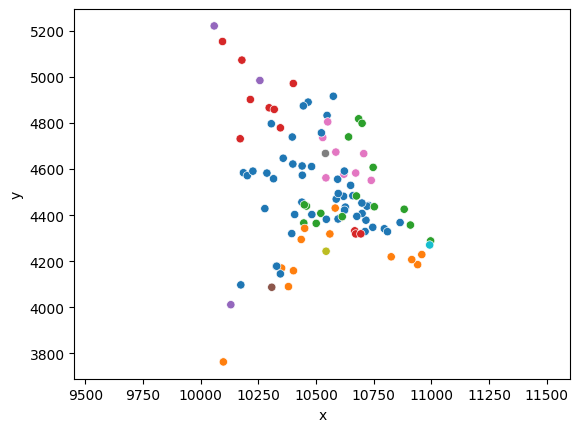

In [5]:
import seaborn as sns
sns.scatterplot(soma_df, x="x", y="y", hue="allenId", palette="tab10", legend=False)
plt.axis('equal')

(10011.240725, 11043.651775, 4497.22813, 7040.88947)

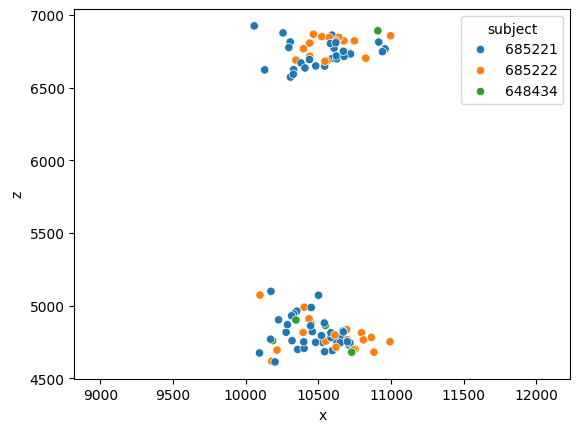

In [6]:
sns.scatterplot(soma_df.sample(frac=1), x="x", y="z", hue="subject", palette="tab10", legend=True)
plt.axis('equal')

## soma sizes

In [7]:
soma_size = pd.read_csv("/data/LC_cells_radii.csv")
# parse string to list

soma_size["radius"] = soma_size["radius"].str.replace("[", "").str.replace("]", "").str.strip().str.split(" ")
# convert to float
soma_size["radius"] = soma_size["radius"].apply(lambda x: [float(i) for i in x if i != ""])
# move column of lists to separate columns
soma_size = soma_size.assign(
    r0=soma_size["radius"].apply(lambda x: x[0]), 
    r1=soma_size["radius"].apply(lambda x: x[1]), 
    r2=soma_size["radius"].apply(lambda x: x[2])
).drop(columns=["radius"])
soma_size = soma_size.query("count==1 and r2<200")
soma_size.shape


/tmp/ipykernel_1241/3979018801.py:4: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  soma_size["radius"] = soma_size["radius"].str.replace("[", "").str.replace("]", "").str.strip().str.split(" ")


(104, 8)

In [8]:
soma_df["id"] = soma_df["file"].apply(lambda x: x.split("/")[-1][:11])
merged = soma_df.merge(soma_size, on="id", how="left")
merged.head()

,x,y,z,allenId,sampleNumber,parentNumber,type,file,zz,subject,id,count,soma,volume,rsquared,r0,r1,r2
0,10547.6826,4832.4666,4863.8392,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N022-6...,4863.8392,648434,N022-648434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10728.7251,4441.3044,4679.5984,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N023-6...,4679.5984,648434,N023-648434,1.0,"[32289.0,10717.0,11379.0]",327720.0055,0.789466,31.682105,34.900041,70.757809
2,10184.9323,4583.9386,4759.3966,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N020-6...,4759.3966,648434,N020-648434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10909.1352,4357.0134,6891.9433,202,0,-1,1,/data/648434_12_5_24/Complete_annotated/N011-6...,4508.0567,648434,N011-648434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10345.3048,4778.6333,4901.0922,1093,0,-1,1,/data/648434_12_5_24/Complete_annotated/N025-6...,4901.0922,648434,N025-648434,1.0,"[31447.0,11515.0,11629.0]",301477.9613,0.935803,28.502765,33.116045,76.250290


(10011.240725, 11043.651775, 4502.418385, 7040.642315)

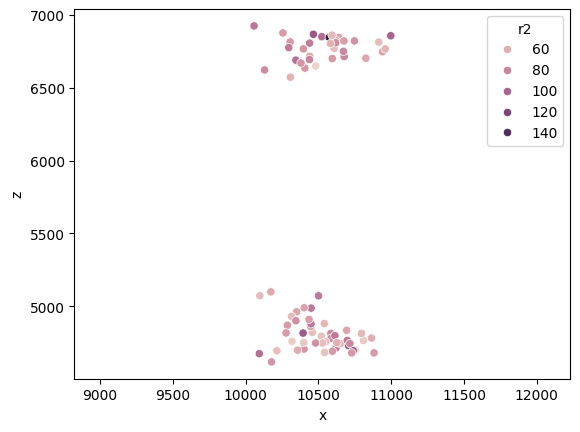

In [9]:
sns.scatterplot(merged.sample(frac=1), x="x", y="z", hue="r2", legend=True)
plt.axis('equal')

(10011.240725, 11043.651775, 4502.418385, 7040.642315)

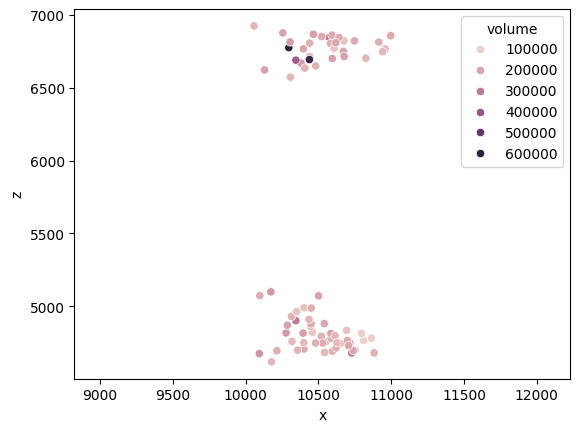

In [10]:
sns.scatterplot(merged.sample(frac=1), x="x", y="z", hue="volume", legend=True)
plt.axis('equal')

## Projections

In [11]:
proj_df = pd.read_csv("/data/LC Morphology Summary.csv")
proj_df.index = proj_df["Graph"].str[:-3]
proj_df.head()

,Unnamed: 0,Graph,somaAP,somaDV,somaML,OLF,Isocortex,HPF,CTXsp,CNU,TH,HY,MB,CB,P,MY,Other,Total Length (cm),Axon Branches,Top Projection
Graph,,,,,,,,,,,,,,,,,,,,
N026-648434,109,N026-648434-PG,9805.1909,5907.0996,4330.8163,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.497431,0.109254,0.330019,4.623159,69,P
N030-685221,58,N030-685221-VM,10058.1685,5220.5902,4474.7315,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.013323,0.000000,0.216441,0.241026,0.524626,6.530727,132,Other
N061-685221,57,N061-685221-YP,10094.2631,5153.0540,4674.3972,0.0,0.0,0.0,0.0,0.0,0.000133,0.0,0.231097,0.000000,0.206456,0.272502,0.269424,9.106368,148,MY
N025-685222,93,N025-685222-SA,10178.2278,5072.3241,4617.7922,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.225847,0.219988,0.162349,0.307591,10.768777,254,Other
N006-648434,108,N006-648434-JN,9709.7926,5022.2970,3873.3075,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.156169,0.203401,0.634154,5.063524,58,Other


In [12]:
soma_df = soma_df.join(proj_df, on="id")
soma_df.head()

,x,y,z,allenId,sampleNumber,parentNumber,type,file,zz,subject,...,TH,HY,MB,CB,P,MY,Other,Total Length (cm),Axon Branches,Top Projection
0,10547.6826,4832.4666,4863.8392,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N022-6...,4863.8392,648434,...,0.000000,0.000000,0.000000,0.714297,0.053801,0.006848,0.143869,13.401983,208.0,CB
0,10728.7251,4441.3044,4679.5984,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N023-6...,4679.5984,648434,...,0.003239,0.004791,0.035697,0.005939,0.018599,0.001311,0.026895,23.957562,345.0,Isocortex
0,10184.9323,4583.9386,4759.3966,771,0,-1,1,/data/648434_12_5_24/Complete_annotated/N020-6...,4759.3966,648434,...,0.005709,0.017364,0.035137,0.000000,0.021068,0.000000,0.012293,13.228512,103.0,Isocortex
0,10909.1352,4357.0134,6891.9433,202,0,-1,1,/data/648434_12_5_24/Complete_annotated/N011-6...,4508.0567,648434,...,0.000000,0.018505,0.023266,0.000283,0.009288,0.019246,0.056825,16.475255,136.0,Isocortex
0,10345.3048,4778.6333,4901.0922,1093,0,-1,1,/data/648434_12_5_24/Complete_annotated/N025-6...,4901.0922,648434,...,0.000000,0.000000,0.000000,0.000000,0.207187,0.194233,0.594055,1.706972,17.0,Other


# Length-based

## distances

In [17]:
from importlib import reload
reload(u)

<module 'utils' from '/root/capsule/code/utils.py'>

In [20]:
pairs[0]

('/data/648434_12_5_24/Complete_annotated/N022-648434-PG.json',
 '/data/648434_12_5_24/Complete_annotated/N023-648434-HD.json')

In [26]:
import tree_comparison.tree_compare as tc
tc.morphology_from_swc = u.load_morphology
result = tc.compare_two_trees(
            pairs[0][0],
            pairs[0][1],
            simFunc="length",
            maxDepth=2,
            orientation=0,
            compartments=[3],
            valid_set_dict=None,
            valid_set_dir='.',
            partition_length=1/2000,
            angle_threshold=None, 
            segment_threshold=None,
            morphology_from_swc=u.load_morphology
        )
result

 14%|█▍        | 4/28 [00:00<00:00, 997.04it/s]

File not found: ./_0_0.mat
File not found: ./_0_0.mat


TypeError: '<' not supported between instances of 'NoneType' and 'NoneType'

In [ ]:
# disable checking code when retrieving cached results
u.compare._check_previous_func_code = lambda *args, **kwargs: True

In [13]:
from joblib import Parallel, delayed

# files = glob("/data/*/Complete_annotated/*.json")[:]
pairs = list(combinations(soma_df["file"], 2))
records = []


In [ ]:


# with Pool(processes=16) as pool:
#     results = list(
#         tqdm(pool.imap(compare, pairs), total=len(pairs), desc="Comparing trees", unit="pair")
#     )
func = lambda x: u.compare(x, "length")
print(f"Number of pairs: {len(pairs)}")
generator = Parallel(n_jobs=16, return_as="generator", verbose=10)(delayed(func)(pair) for pair in pairs)
# results = list(tqdm(generator, desc="Comparing trees", unit="pair", total=len(pairs)))
results = list(generator)
    


In [15]:
import pandas as pd
df = pd.DataFrame.from_records(results).dropna(how="any")
# files = pd.concat([df["file1"], df["file2"]]).unique()
# files.sort()
df.head()

,file1,file2,distance,norm_distance
0,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N023-6...,3913.1817,0.5668
1,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N020-6...,4078.5686,0.5691
2,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N011-6...,3765.9351,0.5263
3,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N025-6...,4370.9496,0.6329
4,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N004-6...,3589.0133,0.5107


In [16]:

files = soma_df["file"]
file_dict = {f: i for i, f in enumerate(files)}
n_files = len(files)
distance_matrix_np = np.zeros((n_files, n_files))
norm_distance_matrix_np = np.zeros((n_files, n_files))

for i, row in df.iterrows():
    file1 = row["file1"]
    file2 = row["file2"]
    distance = row["distance"]
    norm_distance = row["norm_distance"]
    distance_matrix_np[file_dict[file1], file_dict[file2]] = distance
    distance_matrix_np[file_dict[file2], file_dict[file1]] = distance
    norm_distance_matrix_np[file_dict[file1], file_dict[file2]] = norm_distance
    norm_distance_matrix_np[file_dict[file2], file_dict[file1]] = norm_distance
    

## clustering

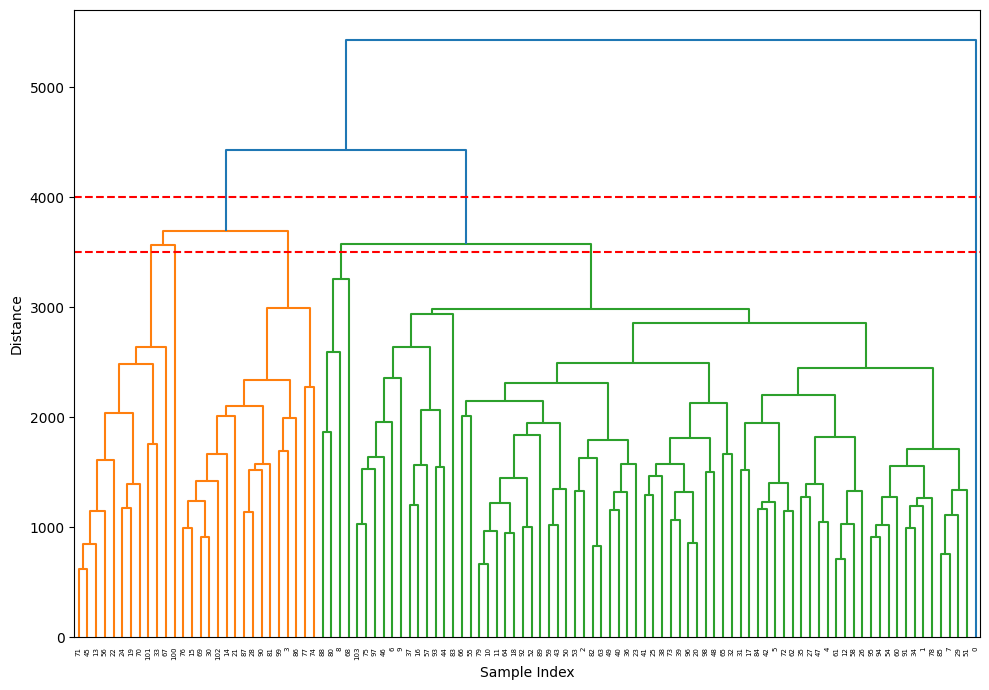

In [17]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert the full distance matrix to a condensed form
# Take only the upper triangular part of the matrix
d = squareform(distance_matrix_np)
linked = linkage(d, 'complete')

# The rest of the code remains as is
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, 
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
# plt.title('Hierarchical Clustering Dendrogram of Neuron Morphologies')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()

# save cluster labels from linkage with distance threshold
from scipy.cluster.hierarchy import fcluster
threshold = 4000  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster"] = fcluster(linked, threshold, criterion='distance')
threshold = 3500  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster2"] = fcluster(linked, threshold, criterion='distance')


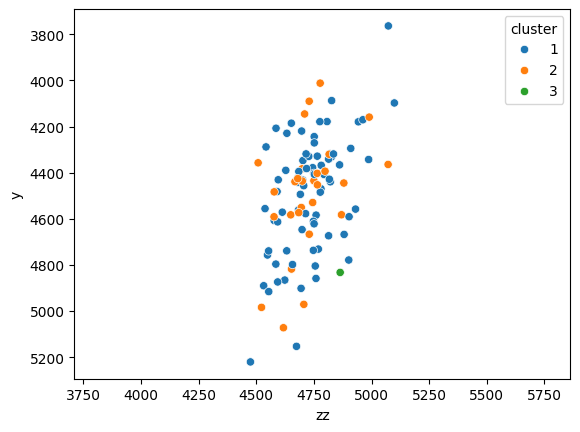

In [18]:
sns.scatterplot(soma_df, x="zz", y="y", hue="cluster", palette="tab10", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

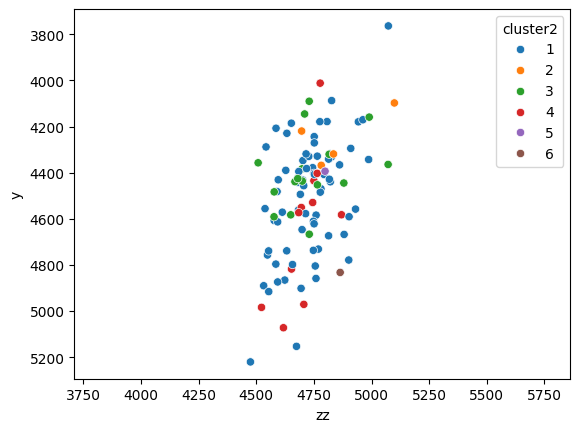

In [19]:
sns.scatterplot(soma_df, x="zz", y="y", hue="cluster2", palette="tab10", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

## unnormalized MDS

In [35]:
def format_plot():
    plt.axis('equal')
    plt.box(False)
    plt.xticks([])
    plt.yticks([])

In [36]:
from sklearn import manifold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

model = manifold.MDS(n_components=2, dissimilarity="precomputed", random_state=42)

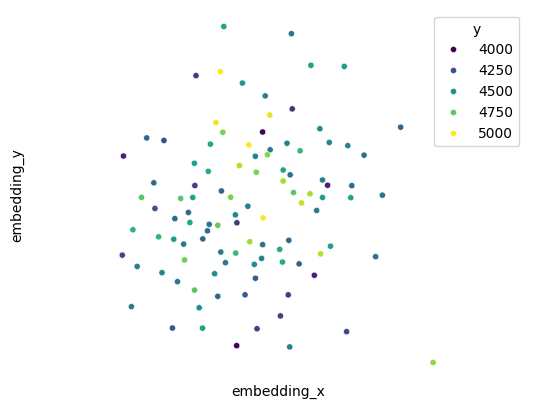

In [37]:
# soma_df_good = merged.dropna(subset=["r2"])
# good = merged["r2"].notna().values.nonzero()[0]
# # index np array with two 1D lists...
# embedding = model.fit_transform(distance_matrix_np[np.ix_(good, good)])

embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()

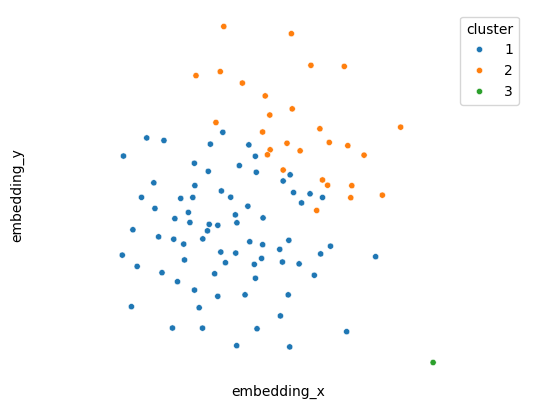

In [38]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

In [48]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)
embedding_highd = model.fit_transform(distance_matrix_np)


Text(0, 0.5, 'Variance Explained')

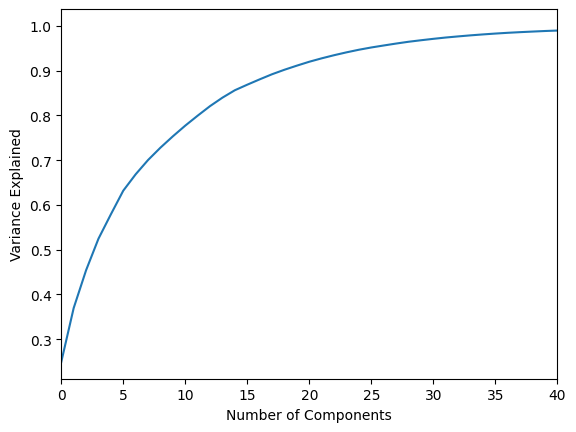

In [49]:

pca = PCA().fit(embedding_highd)
# plot variance explained
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlim(0, 40)
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')

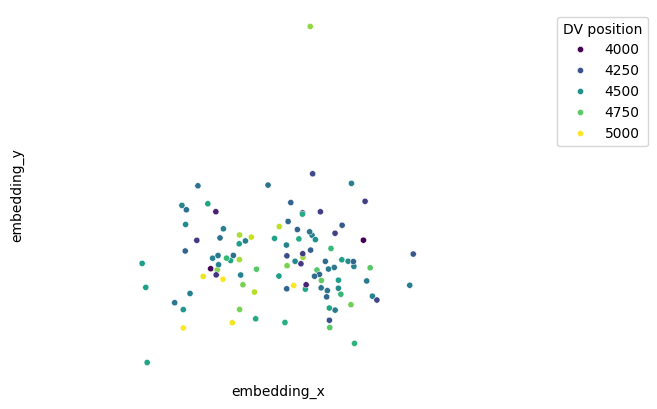

In [ ]:

embedding = PCA(n_components=2).fit_transform(embedding_highd)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
# relabel colors
plt.legend(title="DV position", bbox_to_anchor=(1.05, 1), loc='upper left')
format_plot()


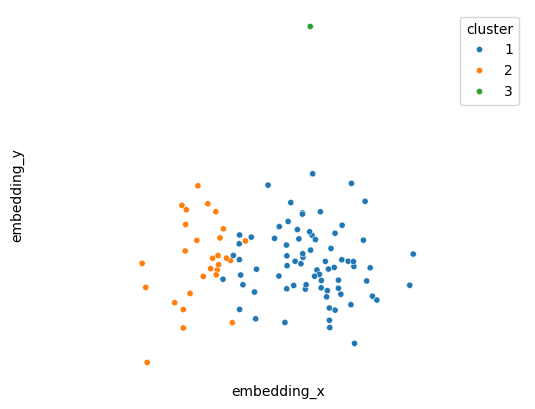

In [ ]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20,)
format_plot()

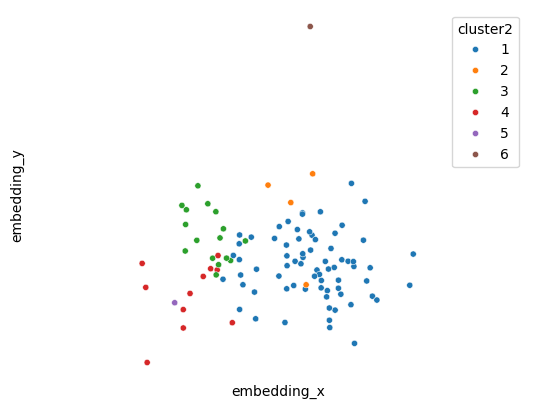

In [41]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster2", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

/tmp/ipykernel_880/1465965529.py:1: FutureWarning: Passing 'suffixes' which cause duplicate columns {'intersections_old'} in the result is deprecated and will raise a MergeError in a future version.
  soma_df = soma_df.join(pd.read_csv("/scratch/sholl_10um.csv", index_col=0), on="Graph", lsuffix="_old")


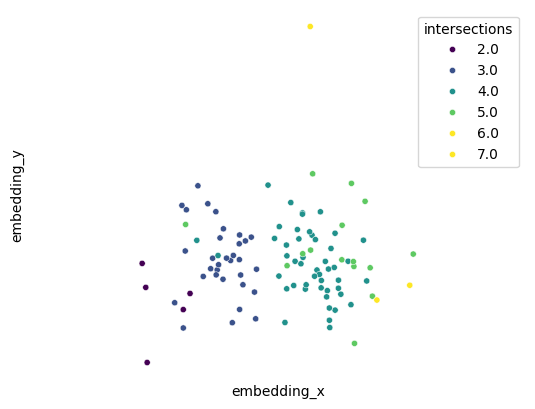

In [45]:
soma_df = soma_df.join(pd.read_csv("/scratch/sholl_10um.csv", index_col=0), on="Graph", lsuffix="_old")
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="intersections", palette="viridis", s=20, hue_norm=(2,6))
format_plot()

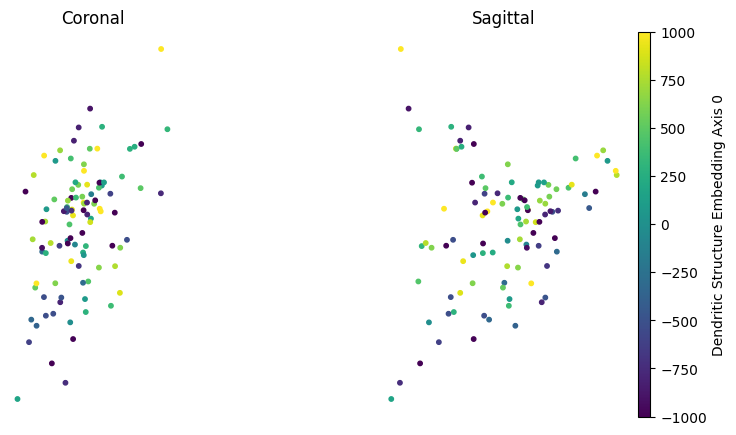

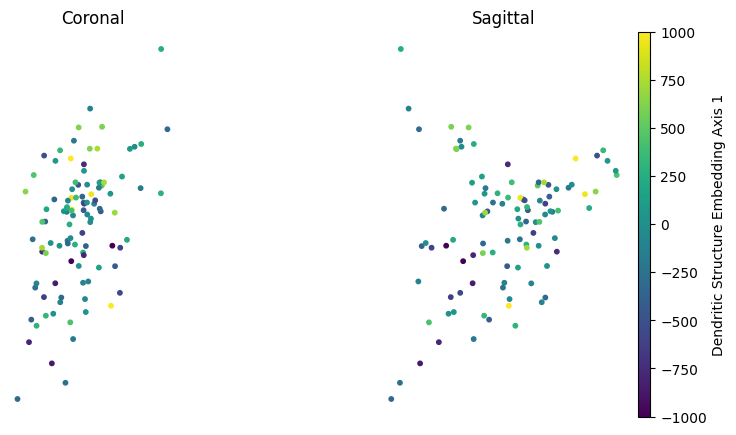

In [29]:
u.two_view_plot(soma_df, embedding, 0, s=10)
u.two_view_plot(soma_df, embedding, 1, s=10)


Text(0.5, 1.0, 'Sagittal views')

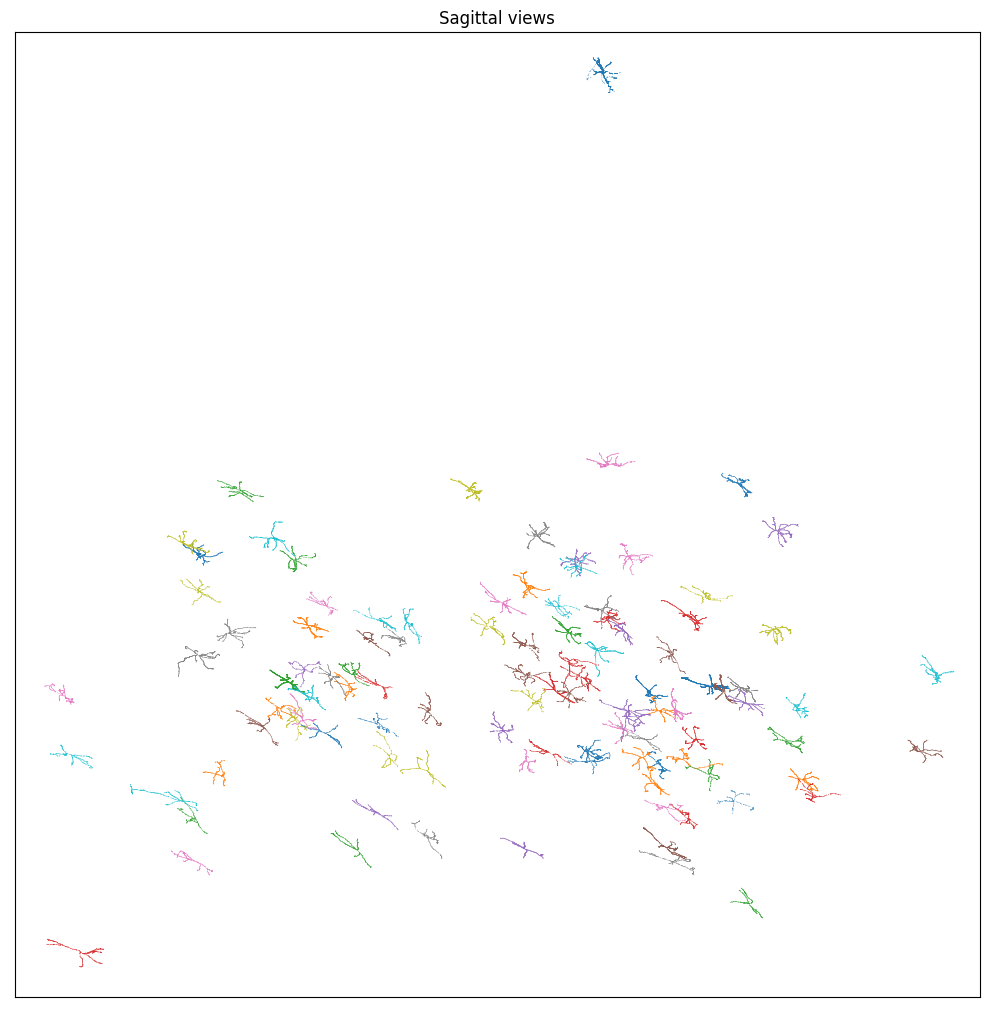

In [49]:
# sagittal
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)
plt.title("Sagittal views")

Text(0.5, 1.0, 'Horizontal views')

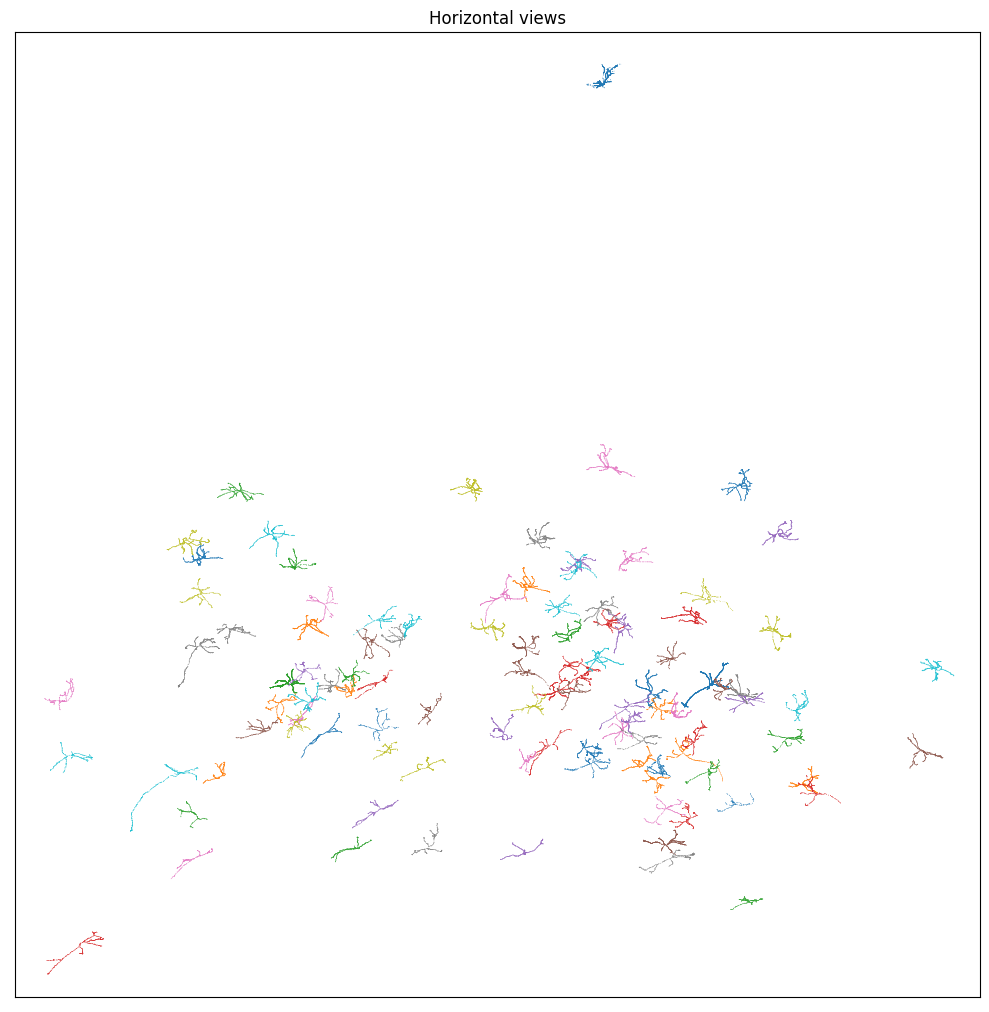

In [50]:
# horizontal
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xz')
plt.title("Horizontal views")

Text(0.5, 1.0, 'Coronal views')

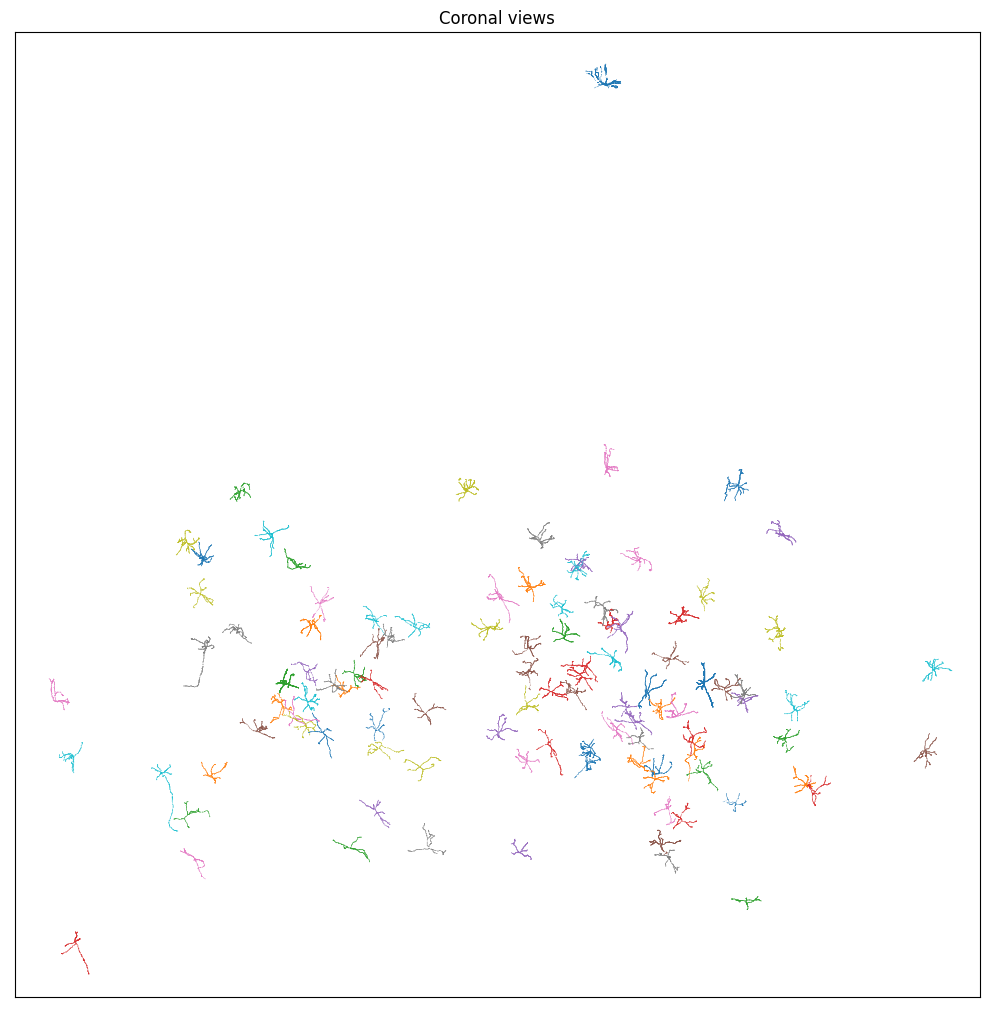

In [48]:
# coronal
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='yz')
plt.title("Coronal views")

## features

In [25]:
from neuron_morphology.feature_extractor.feature_extractor import FeatureExtractor
from neuron_morphology.feature_extractor.data import Data
from neuron_morphology.features.intrinsic import (
    num_branches, num_tips, num_nodes, mean_fragmentation,
    max_branch_order
)
from neuron_morphology.features.branching.bifurcations import (
    num_outer_bifurcations, mean_bifurcation_angle_local, mean_bifurcation_angle_remote
)
from neuron_morphology.features.size import (
    total_length, total_surface_area, total_volume, mean_diameter,
    mean_parent_daughter_ratio, max_euclidean_distance
)
from neuron_morphology.features.path import (
    max_path_distance, early_branch_path, mean_contraction
)
from neuron_morphology.features.soma import calculate_number_of_stems
from neuron_morphology.feature_extractor.marked_feature import specialize
from neuron_morphology.feature_extractor.feature_specialization import DendriteSpec

fe = FeatureExtractor()
fe.register_features(
    [    
    # num_nodes,
    specialize(calculate_number_of_stems, [DendriteSpec]),
    num_branches,
    num_tips,
    mean_fragmentation,
    max_branch_order,
    num_outer_bifurcations,
    mean_bifurcation_angle_local,
    mean_bifurcation_angle_remote,
    total_length,
    # total_surface_area,
    # total_volume,
    # mean_diameter,
    # mean_parent_daughter_ratio,
    max_euclidean_distance,
    max_path_distance,
    early_branch_path,
    mean_contraction,
    ]
)


In [26]:
records = []
for file, morph in morphos.items():
    record = dict(file=file)
    record.update(fe.extract(Data(morph)).results)
    records.append(record)

2025-07-10 23:04:46,139 root         INFO     selected marks: <bound method FeatureExtractionRun.select_marks of <neuron_morphology.feature_extractor.feature_extraction_run.FeatureExtractionRun object at 0x7ff61bb4ee80>>
2025-07-10 23:04:46,140 root         INFO     selected features: ['dendrite.calculate_number_of_stems', 'num_branches', 'num_tips', 'mean_fragmentation', 'max_branch_order', 'num_outer_bifurcations', 'mean_bifurcation_angle_local', 'mean_bifurcation_angle_remote', 'total_length', 'max_euclidean_distance', 'max_path_distance', 'early_branch_path', 'mean_contraction']
2025-07-10 23:04:46,185 root         INFO     selected marks: <bound method FeatureExtractionRun.select_marks of <neuron_morphology.feature_extractor.feature_extraction_run.FeatureExtractionRun object at 0x7ff61bb4edf0>>
2025-07-10 23:04:46,186 root         INFO     selected features: ['dendrite.calculate_number_of_stems', 'num_branches', 'num_tips', 'mean_fragmentation', 'max_branch_order', 'num_outer_bifu

In [27]:
feat_df = pd.DataFrame.from_records(records).set_index("file")
soma_df = soma_df.join(feat_df, on="file")

/opt/conda/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: ConstantInputWarning: Each of the input arrays is constant; the F statistic is not defined or infinite
  res = hypotest_fun_out(*samples, **kwds)
2025-07-10 23:07:17,677 matplotlib.category INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 23:07:17,683 matplotlib.category INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 23:07:17,712 matplotlib.category INFO     Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-07-10 23:07:17,718 matplotlib.category INFO 

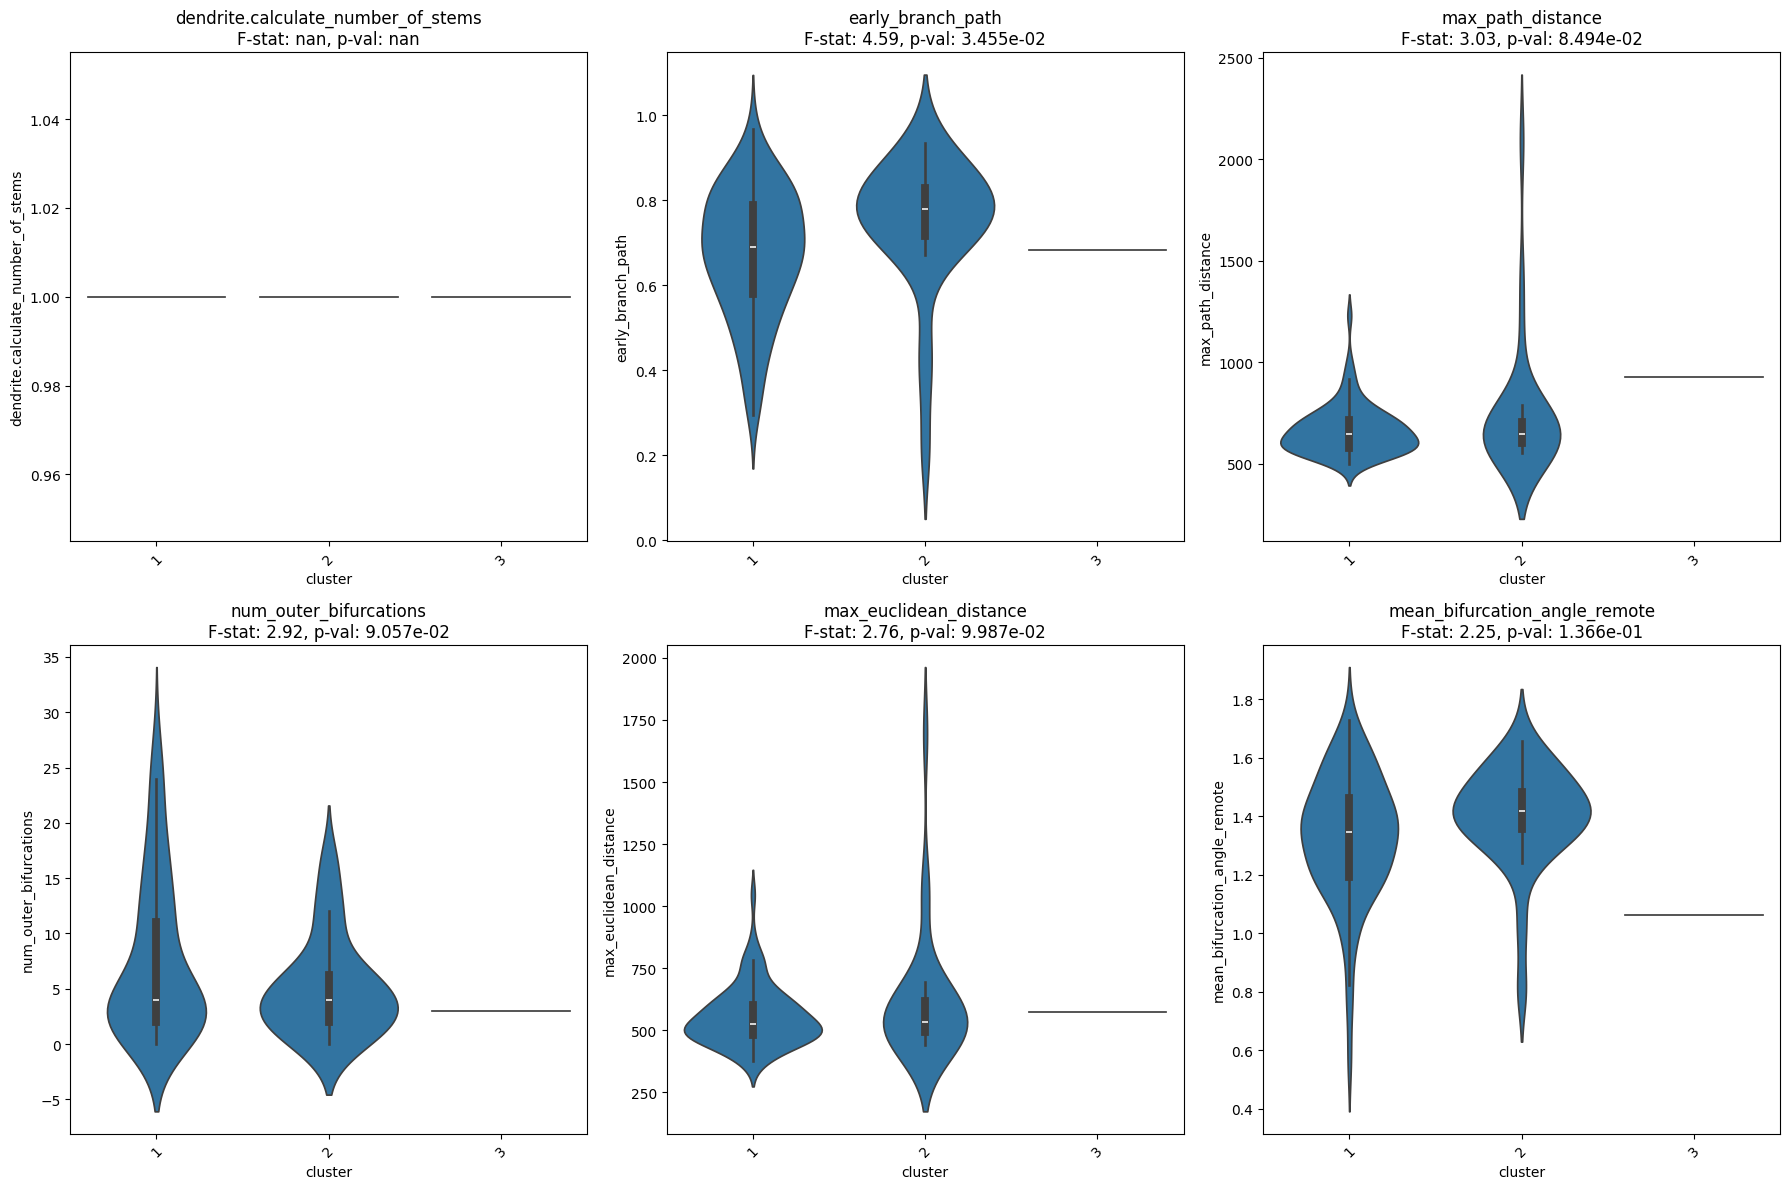

Features ranked by cluster differentiation (F-statistic):
 1. dendrite.calculate_number_of_stems F=   nan p=nan
 2. early_branch_path              F=  4.59 p=3.455e-02
 3. max_path_distance              F=  3.03 p=8.494e-02
 4. num_outer_bifurcations         F=  2.92 p=9.057e-02
 5. max_euclidean_distance         F=  2.76 p=9.987e-02
 6. mean_bifurcation_angle_remote  F=  2.25 p=1.366e-01
 7. num_branches                   F=  2.19 p=1.421e-01
 8. num_tips                       F=  2.19 p=1.421e-01
 9. mean_fragmentation             F=  0.75 p=3.870e-01
10. mean_contraction               F=  0.53 p=4.704e-01
11. total_length                   F=  0.13 p=7.155e-01
12. mean_bifurcation_angle_local   F=  0.08 p=7.715e-01
13. max_branch_order               F=  0.00 p=9.689e-01


In [31]:
from scipy import stats

# Get the feature columns (excluding non-feature columns)
feature_cols = feat_df.columns.tolist()

# Calculate F-statistics for each feature across clusters
f_stats = []
clusters = [1,2]
for feature in feature_cols:
    groups = [soma_df[soma_df['cluster'] == cluster][feature].values 
              for cluster in clusters]
    f_stat, p_val = stats.f_oneway(*groups)
    f_stats.append((feature, f_stat, p_val))

# Sort by F-statistic (descending)
f_stats.sort(key=lambda x: x[1], reverse=True)

# Plot violin plots for top differentiating features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (feature, f_stat, p_val) in enumerate(f_stats[:6]):
    sns.violinplot(data=soma_df, x='cluster', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature}\nF-stat: {f_stat:.2f}, p-val: {p_val:.3e}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print ranking of features by differentiation
print("Features ranked by cluster differentiation (F-statistic):")
for i, (feature, f_stat, p_val) in enumerate(f_stats):
    print(f"{i+1:2d}. {feature:30s} F={f_stat:6.2f} p={p_val:.3e}")

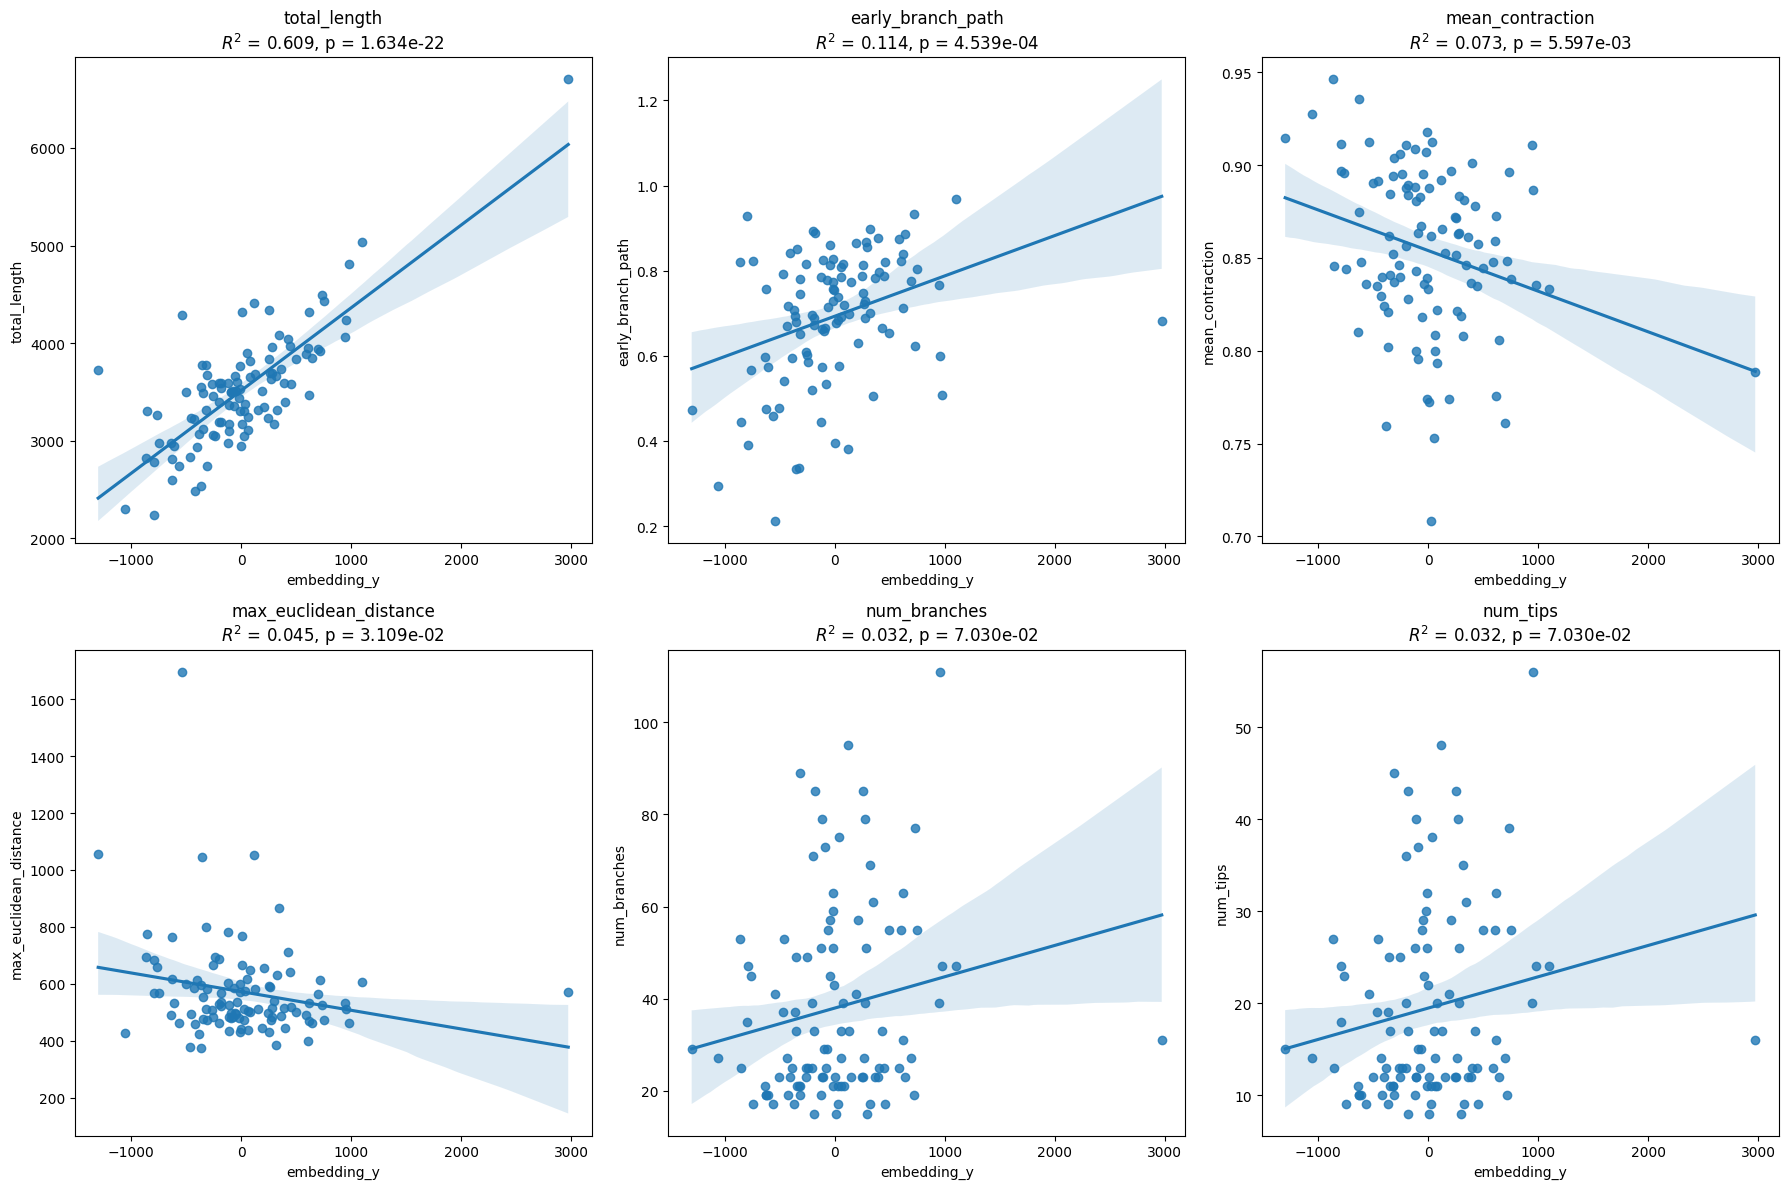

Features ranked by R-squared with embedding_y:
 1. total_length                   R²= 0.609 p=1.634e-22
 2. early_branch_path              R²= 0.114 p=4.539e-04
 3. mean_contraction               R²= 0.073 p=5.597e-03
 4. max_euclidean_distance         R²= 0.045 p=3.109e-02
 5. num_branches                   R²= 0.032 p=7.030e-02
 6. num_tips                       R²= 0.032 p=7.030e-02
 7. mean_bifurcation_angle_local   R²= 0.015 p=2.128e-01
 8. max_path_distance              R²= 0.012 p=2.699e-01
 9. max_branch_order               R²= 0.012 p=2.764e-01
10. mean_bifurcation_angle_remote  R²= 0.003 p=5.822e-01
11. num_outer_bifurcations         R²= 0.002 p=6.180e-01
12. mean_fragmentation             R²= 0.002 p=6.428e-01


In [58]:
from scipy import stats

# Get the feature columns (excluding non-feature columns)
feature_cols = ['num_branches', 'num_tips', 'mean_fragmentation', 'max_branch_order', 
                'num_outer_bifurcations', 'mean_bifurcation_angle_local', 
                'mean_bifurcation_angle_remote', 'total_length', 'max_euclidean_distance', 
                'max_path_distance', 'early_branch_path', 'mean_contraction']
x = "embedding_y"
# Calculate R-squared values for all features vs x
r_squared_values = []
for feature in feature_cols:
    # Remove NaN values for this feature
    clean_data = soma_df.dropna(subset=[x, feature])
    
    if len(clean_data) > 1:  # Need at least 2 points for regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(clean_data[x], clean_data[feature])
        r_squared_values.append((feature, r_value**2, p_value))
    else:
        r_squared_values.append((feature, 0, 1))

# Sort by R-squared value (descending)
r_squared_values.sort(key=lambda x: x[1], reverse=True)

# Plot the top 6 features with highest R-squared values
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (feature, r_sq, p_val) in enumerate(r_squared_values[:6]):
    clean_data = soma_df.dropna(subset=[x, feature])
    
    sns.regplot(data=clean_data, x=x, y=feature, ax=axes[i])
    axes[i].set_title(f'{feature}\n$R^2$ = {r_sq:.3f}, p = {p_val:.3e}')
    axes[i].set_xlabel(x)

plt.tight_layout()
plt.show()

# Print ranking of features by R-squared
print(f"Features ranked by R-squared with {x}:")
for i, (feature, r_sq, p_val) in enumerate(r_squared_values):
    print(f"{i+1:2d}. {feature:30s} R²={r_sq:6.3f} p={p_val:.3e}")

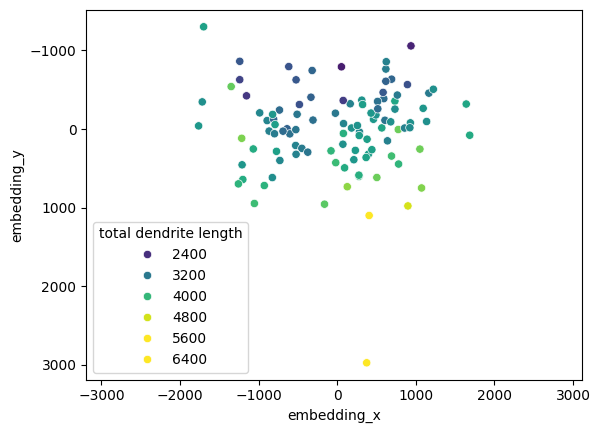

In [62]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="total_length", palette="viridis", legend=True, hue_norm=(2000,5000 ))  
plt.axis('equal')
plt.legend(title="total dendrite length")
plt.gca().invert_yaxis()

Text(0.5, 0, 'total dendrite length')

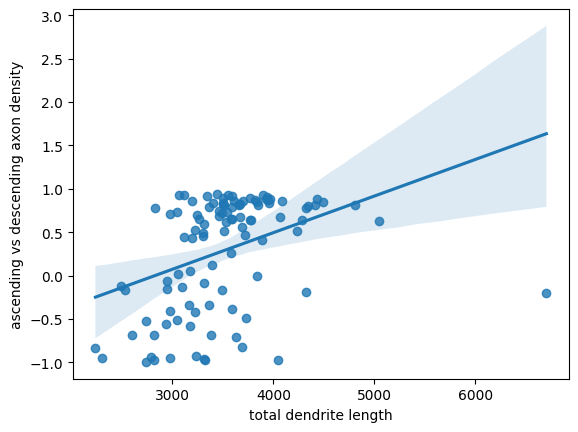

In [65]:
sns.regplot(soma_df, x="total_length", y="cortex_diff")
plt.ylabel("ascending vs descending axon density")
plt.xlabel("total dendrite length")

In [ ]:
    """ Returns the ratio of the longest 'short' branch from a bifurcation to
    the maximum path length of the tree. In other words, for each bifurcation,
    the maximum path length below that branch is calculated, and the shorter of
    these values is used. The maximum of these short values is divided by the
    maximum path length.
    """

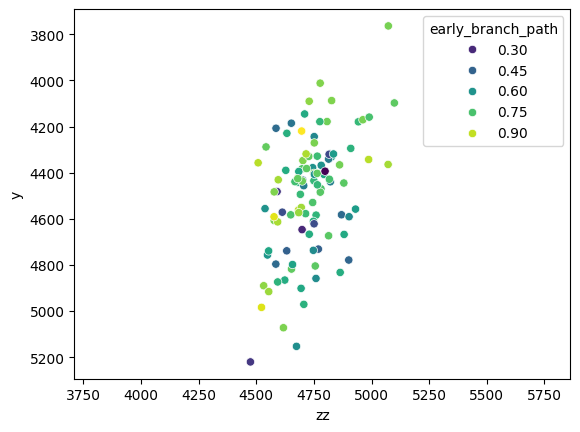

In [ ]:
sns.scatterplot(soma_df, x="zz", y="y", hue="early_branch_path", palette="viridis", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

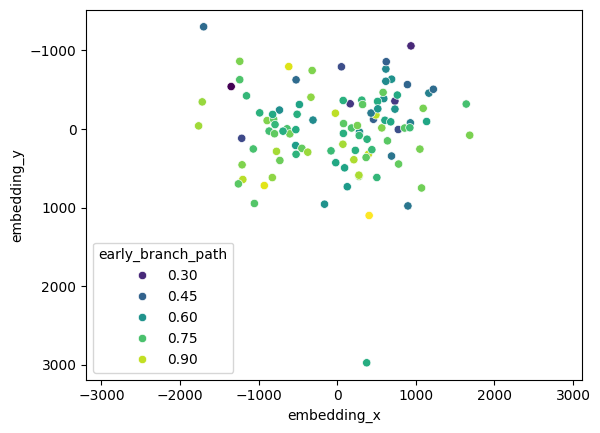

In [ ]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="early_branch_path", palette="viridis", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

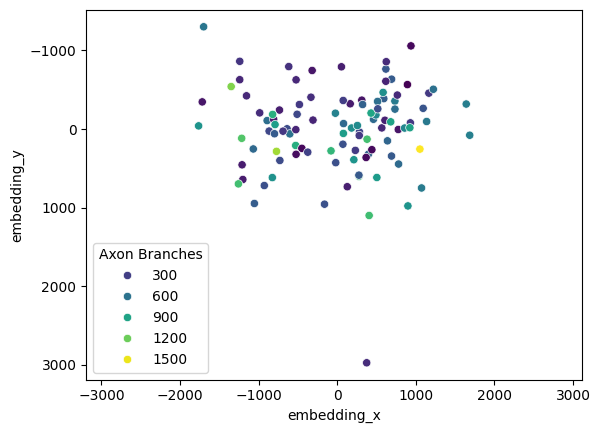

In [41]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="Axon Branches", palette="viridis", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

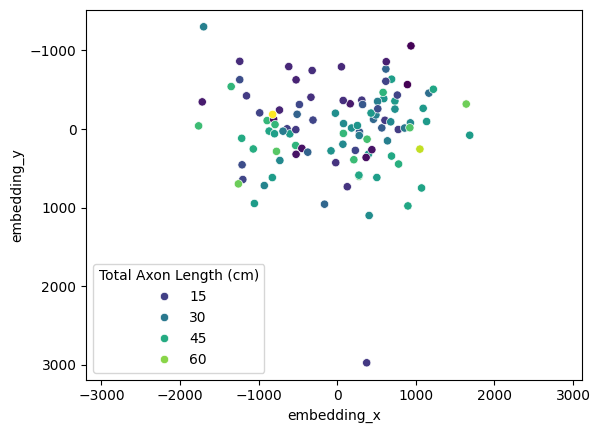

In [47]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="Total Length (cm)", palette="viridis", legend=True)
plt.legend(title="Total Axon Length (cm)")
plt.axis('equal')
plt.gca().invert_yaxis()

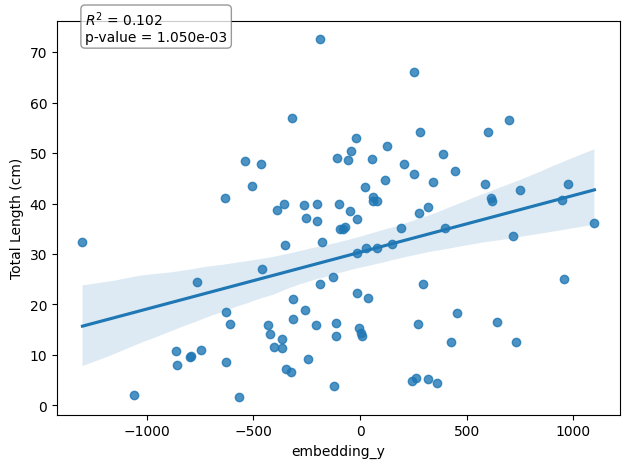

In [42]:
import scipy.stats as stats
# Define x and y variables as parameters
x_var = "embedding_y"
y_var = "Total Length (cm)"
df = soma_df.dropna(subset=[x_var, y_var]).loc[lambda df: df[x_var] < 2000]

# Calculate regression stats
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df[x_var], df[y_var]
)

# Create the regression plot
sns.regplot(df, x=x_var, y=y_var,)

# Add r-squared and p-value annotation
plt.annotate(f"$R^2$ = {r_value**2:.3f}\np-value = {p_value:.3e}", 
             xy=(0.05, 0.95), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()

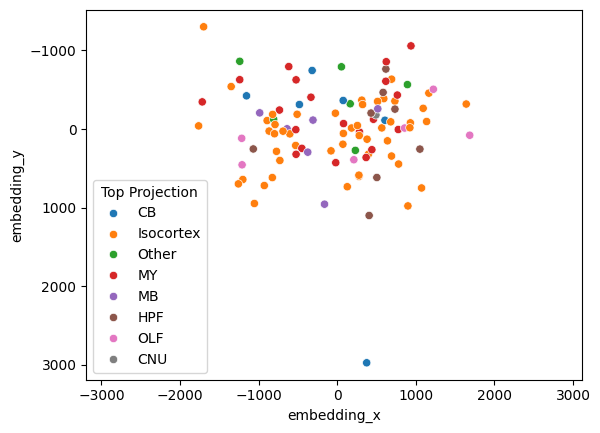

In [35]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="Top Projection", legend=True)
plt.axis('equal')
plt.gca().invert_yaxis()

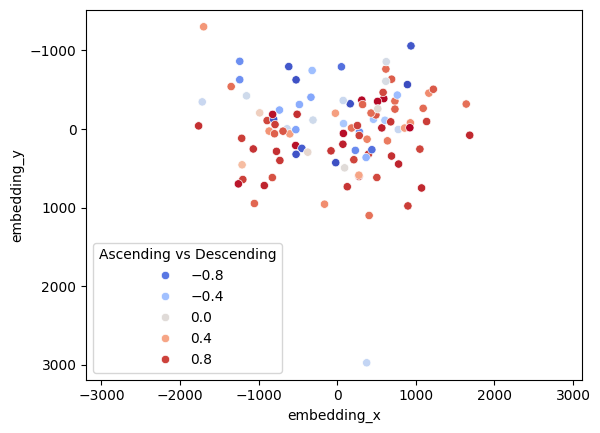

In [46]:
# correlated blocks of projection features to project down to 1D
soma_df["cortex_diff"] = soma_df[["OLF","Isocortex","HPF","CTXsp","CNU","TH","HY","MB"]].sum(axis=1) - soma_df[["P","MY","Other"]].sum(axis=1)
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cortex_diff", legend=True, palette="coolwarm")
plt.axis('equal')
plt.legend(title="Ascending vs Descending")
plt.gca().invert_yaxis()

Text(31.097222222222214, 0.5, 'Ascending vs descending projection density')

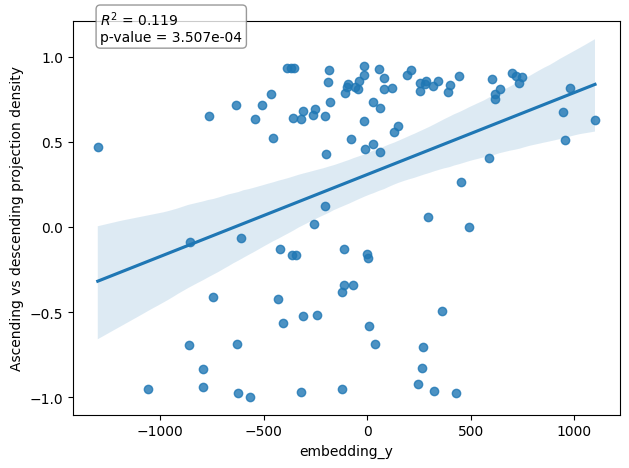

In [51]:
import scipy.stats as stats
# Define x and y variables as parameters
x_var = "embedding_y"
y_var = "cortex_diff"
df = soma_df.dropna(subset=[x_var, y_var]).loc[lambda df: df[x_var] < 2000]

# Calculate regression stats
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df[x_var], df[y_var]
)

# Create the regression plot
sns.regplot(df, x=x_var, y=y_var,)

# Add r-squared and p-value annotation
plt.annotate(f"$R^2$ = {r_value**2:.3f}\np-value = {p_value:.3e}", 
             xy=(0.05, 0.95), xycoords='axes fraction', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.ylabel("Ascending vs descending projection density")

In [67]:
soma_df.to_csv("/results/LC_exaspim_dendrite_features.csv")

# alternative embeddings

## ICA, FA

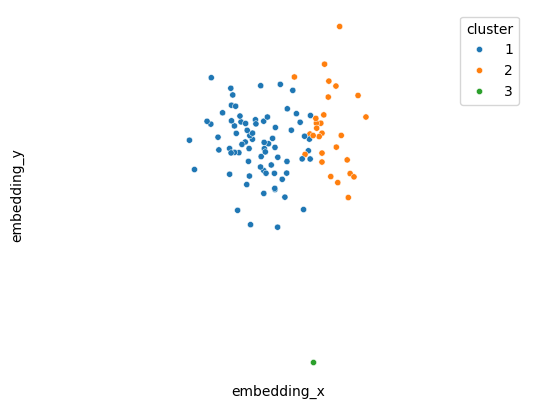

In [ ]:

from sklearn.decomposition import FastICA, FactorAnalysis
embedding = FastICA(n_components=2).fit_transform(embedding_highd)

soma_df[["embedding_x", "embedding_y"]] = embedding

# sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
# plt.legend(title="DV position", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20,)
format_plot()


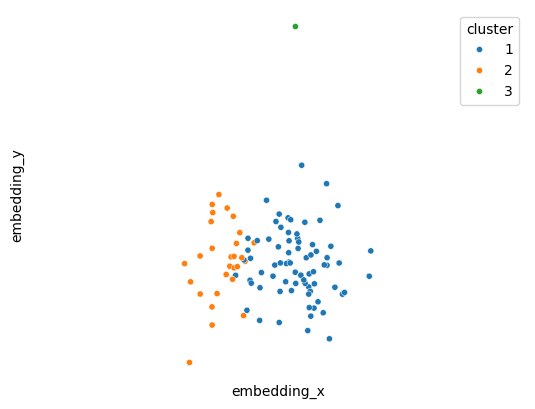

In [ ]:

from sklearn.decomposition import FastICA, FactorAnalysis
embedding = FactorAnalysis(n_components=2).fit_transform(embedding_highd)

soma_df[["embedding_x", "embedding_y"]] = embedding

# sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
# plt.legend(title="DV position", bbox_to_anchor=(1.05, 1), loc='upper left')
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20,)

format_plot()


## normalized MDS

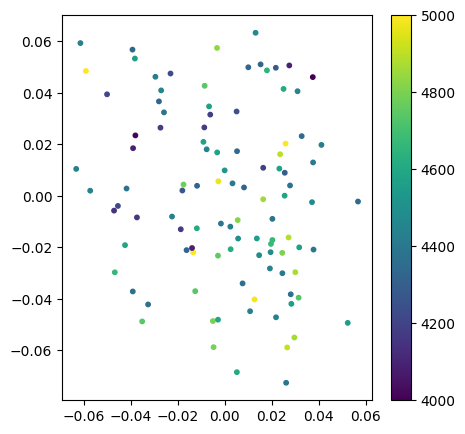

In [35]:
embedding = model.fit_transform(norm_distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

In [36]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)

embedding_highd = model.fit_transform(norm_distance_matrix_np)
embedding = PCA(n_components=2).fit_transform(embedding_highd)


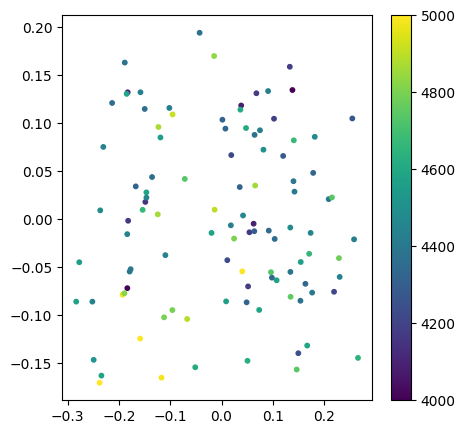

In [37]:
# DV position
plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

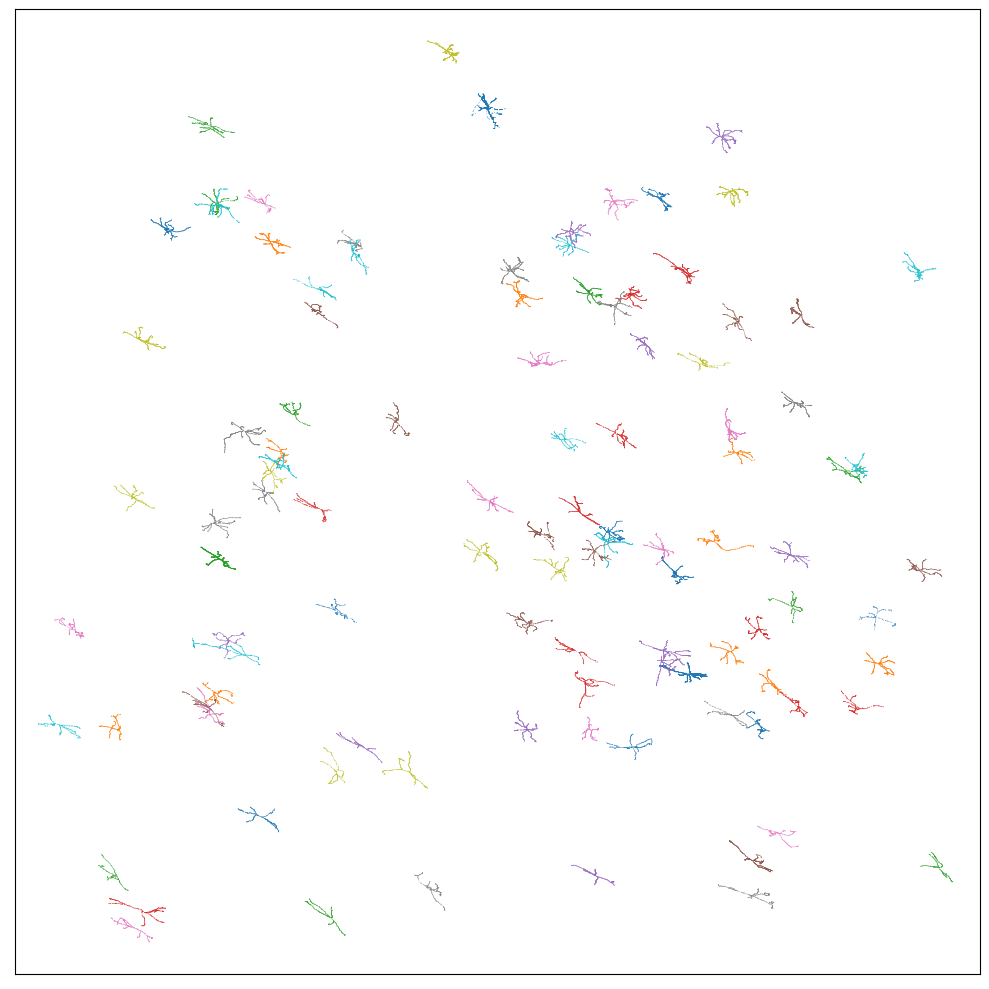

In [38]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

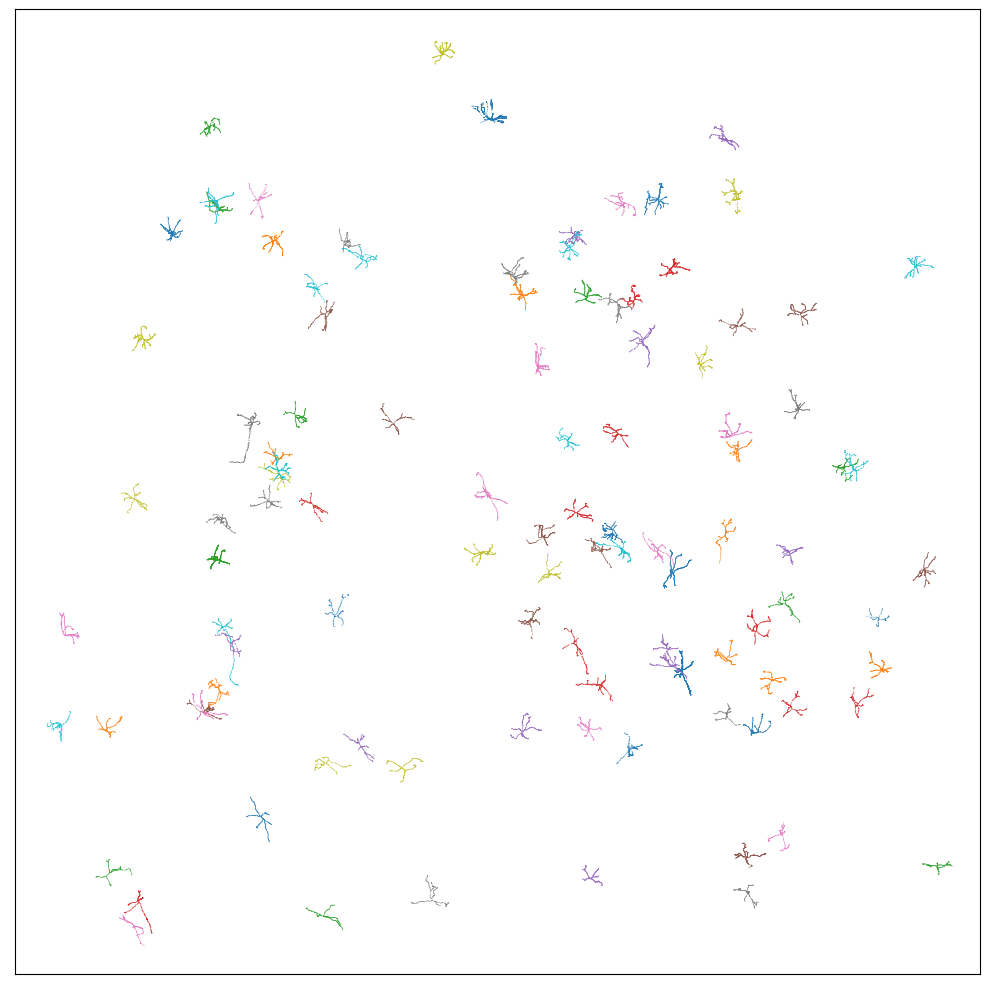

In [39]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='yz')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

## unnormalized TSNE

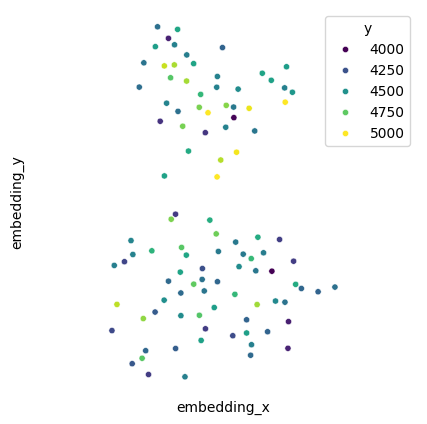

In [40]:
model = manifold.TSNE(n_components=2, metric="precomputed", init="random", random_state=42, perplexity=10)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()


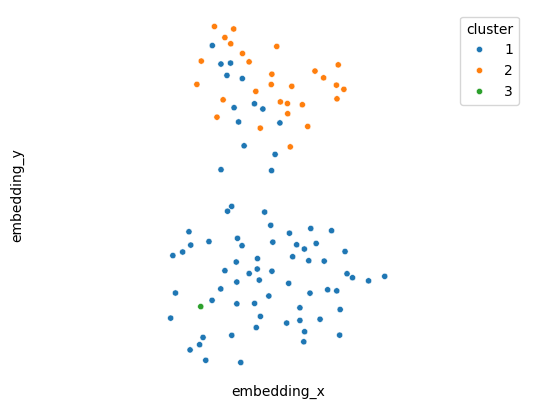

In [41]:

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

## unnormalized UMAP

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


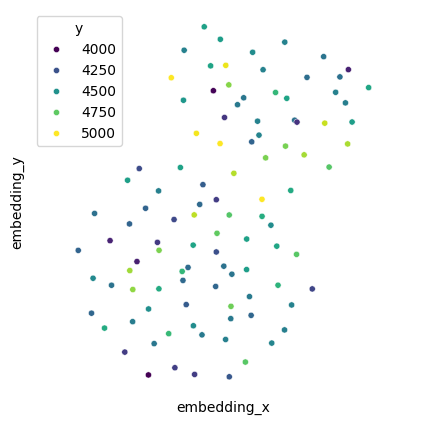

In [42]:
from umap import UMAP
model = UMAP(n_components=2, metric="precomputed", random_state=42, min_dist=1)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()

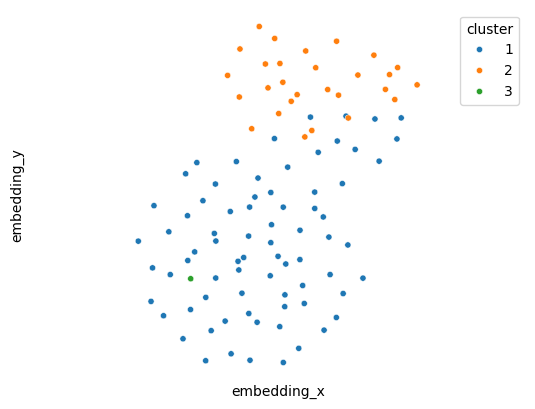

In [43]:
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

# Convex

## distances

In [44]:

func = lambda x: u.compare(x, "convex")
print(f"Number of pairs: {len(pairs)}")
generator = Parallel(n_jobs=16, return_as="generator", verbose=10)(delayed(func)(pair) for pair in pairs)
# results = list(tqdm(generator, desc="Comparing trees", unit="pair", total=len(pairs)))
results = list(generator)



Number of pairs: 5356


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Batch computation too fast (0.030508756637573242s.) Setting batch_size=2.
[Parallel(n_jobs=16)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  29 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Batch computation too fast (0.06962990760803223s.) Setting batch_size=4.
[Parallel(n_jobs=16)]: Done  48 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  74 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Batch computation too fast (0.12941861152648926s.) Setting batch_size=8.
[Parallel(n_jobs=16)]: Done 104 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 164 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 224 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 360 tasks      | elapsed:    0.7s
[Parallel(n_jobs=16)]: Done 496 tasks      | elapsed:    0.9s
[Parallel(n_jo

In [45]:
import pandas as pd
df = pd.DataFrame.from_records(results).dropna(how="any")
# files = pd.concat([df["file1"], df["file2"]]).unique()
# files.sort()
df.head()

,file1,file2,distance,norm_distance
0,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N023-6...,7894.3504,0.8875
1,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N020-6...,8055.0455,0.8798
2,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N011-6...,8339.4845,0.8832
3,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N025-6...,7447.2938,0.8819
4,/data/648434_12_5_24/Complete_annotated/N022-6...,/data/648434_12_5_24/Complete_annotated/N004-6...,8172.6434,0.8770


In [46]:

files = soma_df["file"]
file_dict = {f: i for i, f in enumerate(files)}
n_files = len(files)
distance_matrix_np = np.zeros((n_files, n_files))
norm_distance_matrix_np = np.zeros((n_files, n_files))

for i, row in df.iterrows():
    file1 = row["file1"]
    file2 = row["file2"]
    distance = row["distance"]
    norm_distance = row["norm_distance"]
    distance_matrix_np[file_dict[file1], file_dict[file2]] = distance
    distance_matrix_np[file_dict[file2], file_dict[file1]] = distance
    norm_distance_matrix_np[file_dict[file1], file_dict[file2]] = norm_distance
    norm_distance_matrix_np[file_dict[file2], file_dict[file1]] = norm_distance
    

## clustering

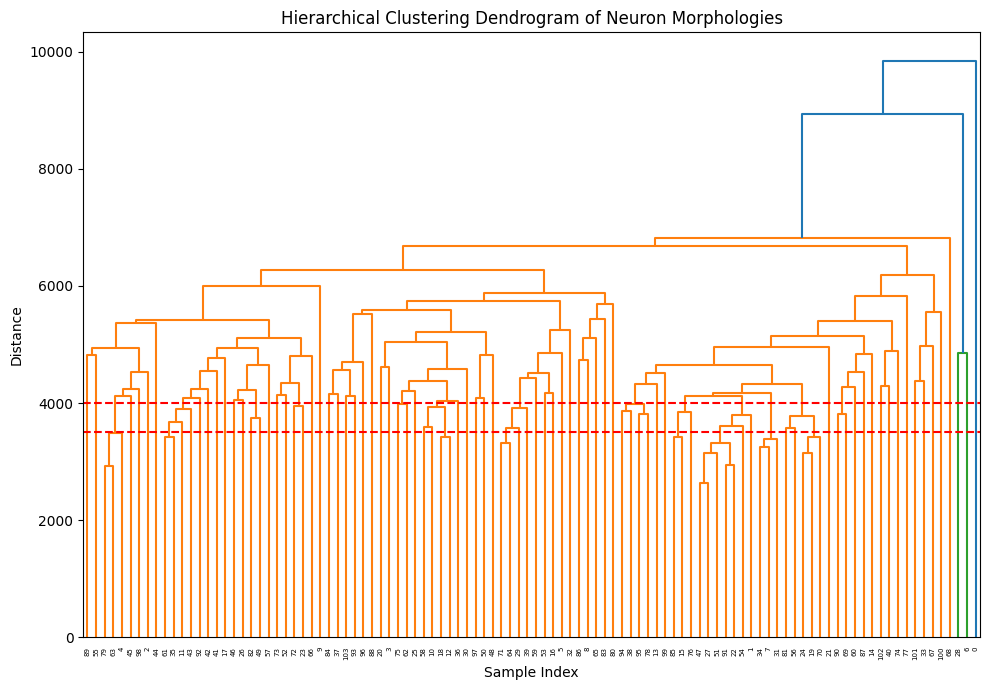

In [48]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

# Convert the full distance matrix to a condensed form
# Take only the upper triangular part of the matrix
d = squareform(distance_matrix_np)
linked = linkage(d, 'complete')

# The rest of the code remains as is
# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, 
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram of Neuron Morphologies')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()

# save cluster labels from linkage with distance threshold
from scipy.cluster.hierarchy import fcluster
threshold = 4000  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster"] = fcluster(linked, threshold, criterion='distance')
threshold = 3500  # Set your desired threshold
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
soma_df["cluster2"] = fcluster(linked, threshold, criterion='distance')


## unnormalized MDS

In [50]:
def format_plot():
    plt.axis('equal')
    plt.box(False)
    plt.xticks([])
    plt.yticks([])

In [51]:
from sklearn import manifold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

model = manifold.MDS(n_components=2, dissimilarity="precomputed", random_state=42)

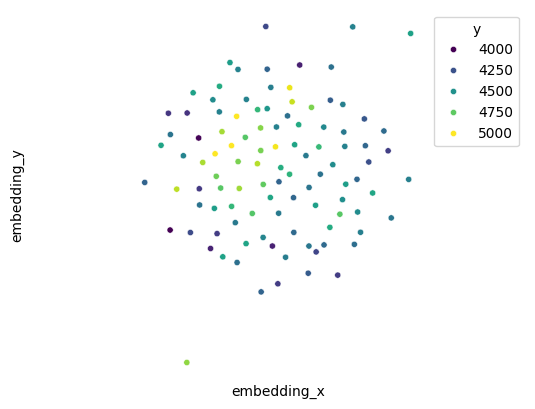

In [52]:
# soma_df_good = merged.dropna(subset=["r2"])
# good = merged["r2"].notna().values.nonzero()[0]
# # index np array with two 1D lists...
# embedding = model.fit_transform(distance_matrix_np[np.ix_(good, good)])

embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()

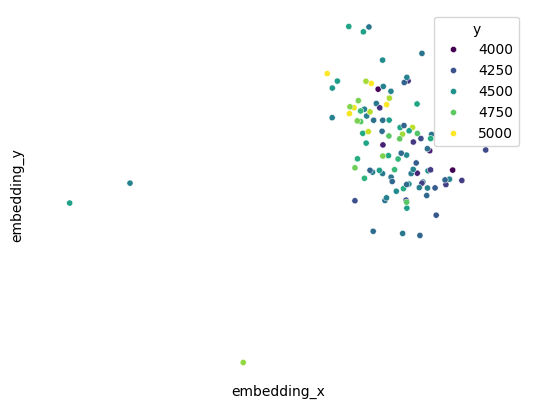

In [54]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)

embedding_highd = model.fit_transform(distance_matrix_np)
embedding = PCA(n_components=2).fit_transform(embedding_highd)
soma_df[["embedding_x", "embedding_y"]] = embedding

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()


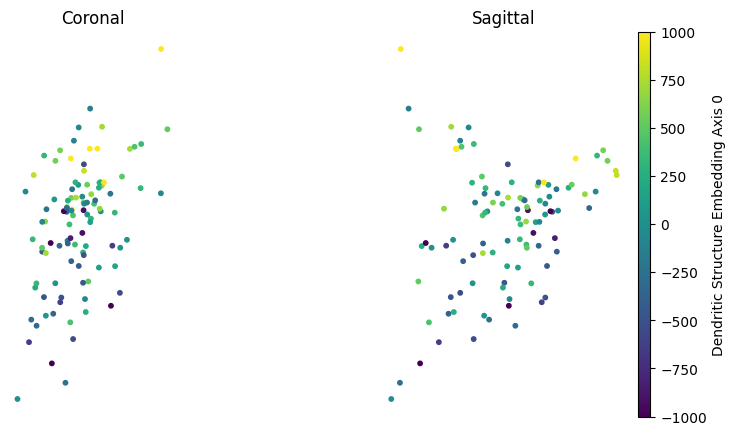

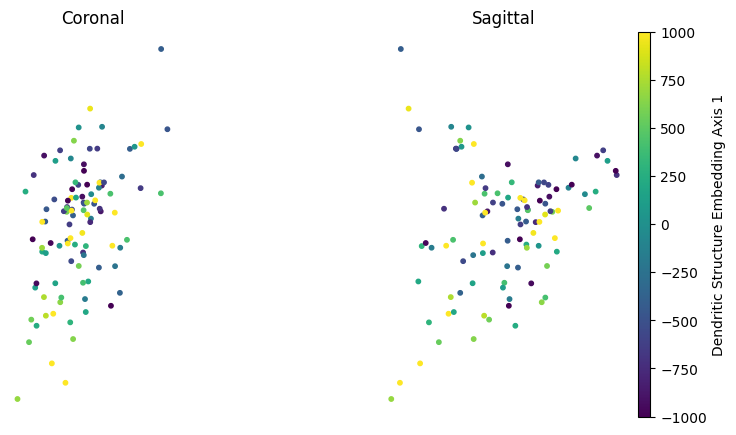

In [57]:
u.two_view_plot(soma_df, embedding, 0, s=10)
u.two_view_plot(soma_df, embedding, 1, s=10)


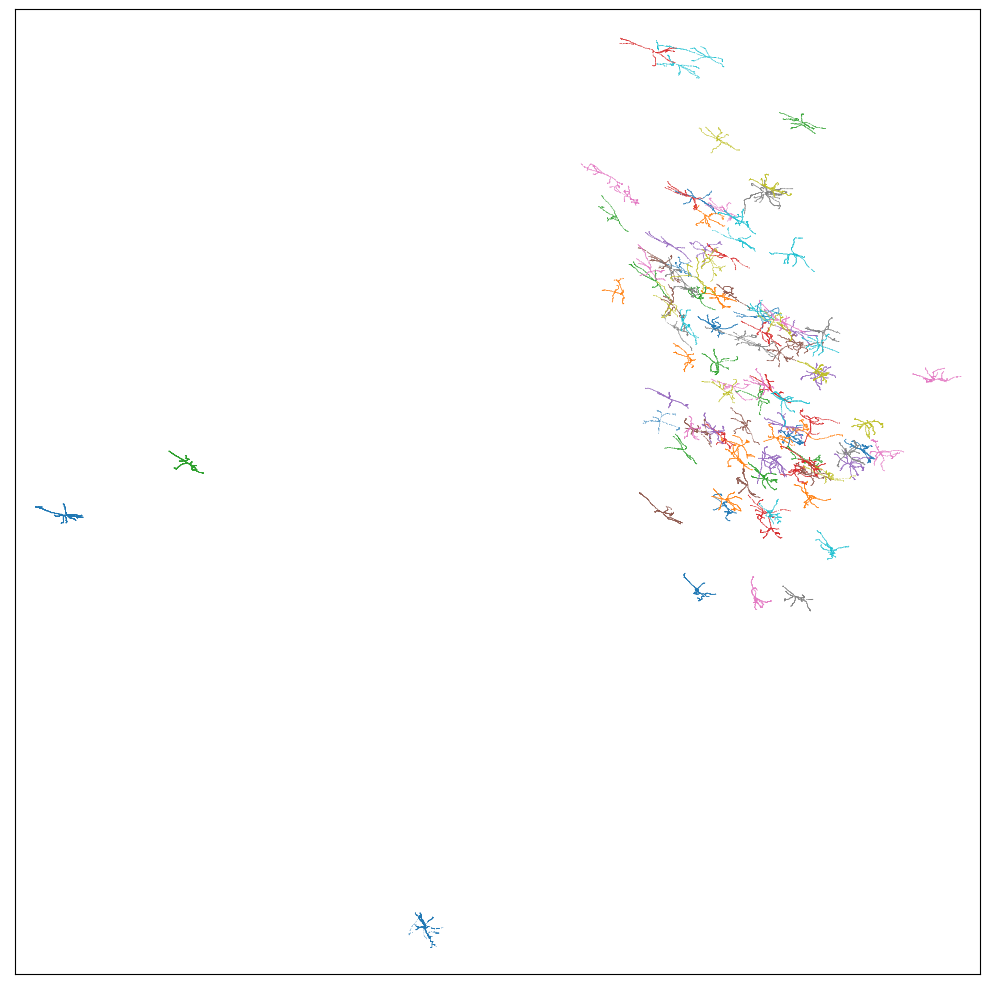

In [58]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

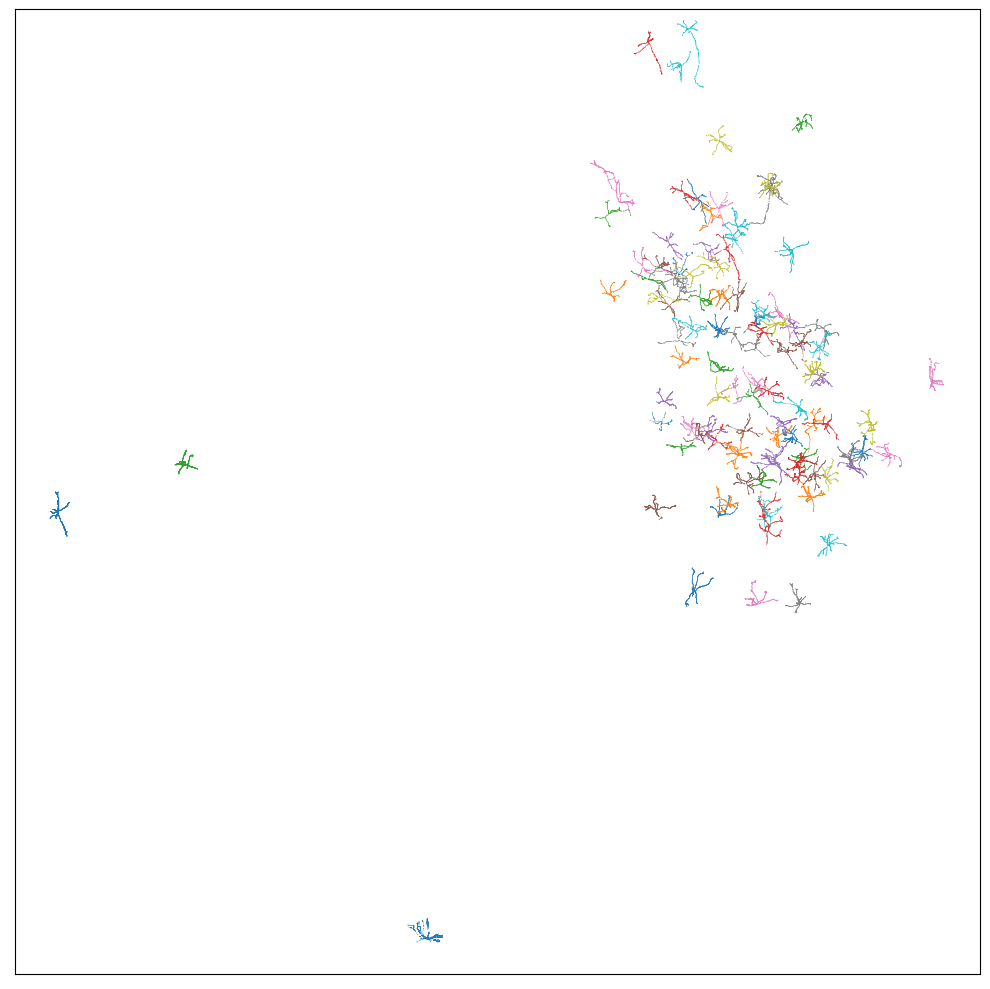

In [60]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='yz')

## normalized MDS

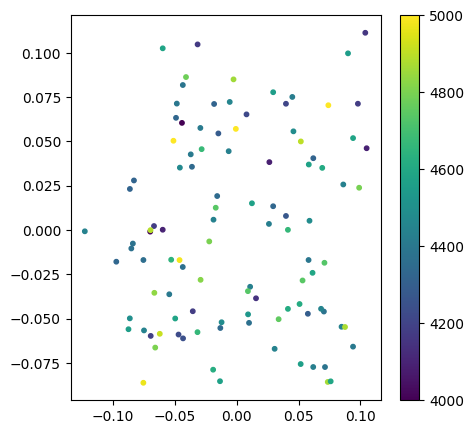

In [61]:
embedding = model.fit_transform(norm_distance_matrix_np)

plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

In [62]:
n_components=100
model = manifold.MDS(n_components=n_components, dissimilarity="precomputed", random_state=42)

embedding_highd = model.fit_transform(norm_distance_matrix_np)
embedding = PCA(n_components=2).fit_transform(embedding_highd)


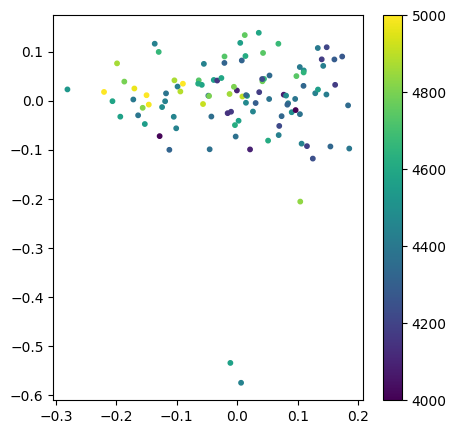

In [63]:
# DV position
plt.figure(figsize=(5, 5))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"])
clim=(4000, 5000)
plt.clim(clim)
plt.colorbar()

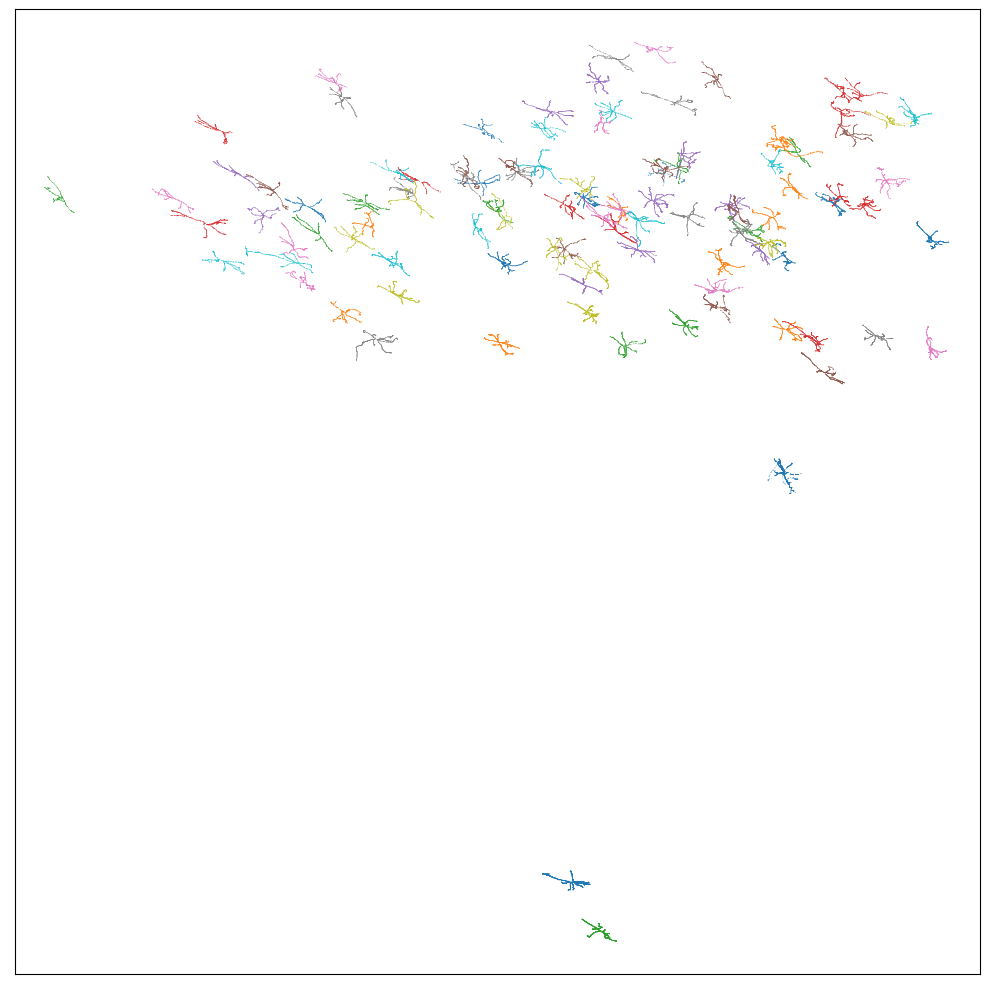

In [64]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='xy')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

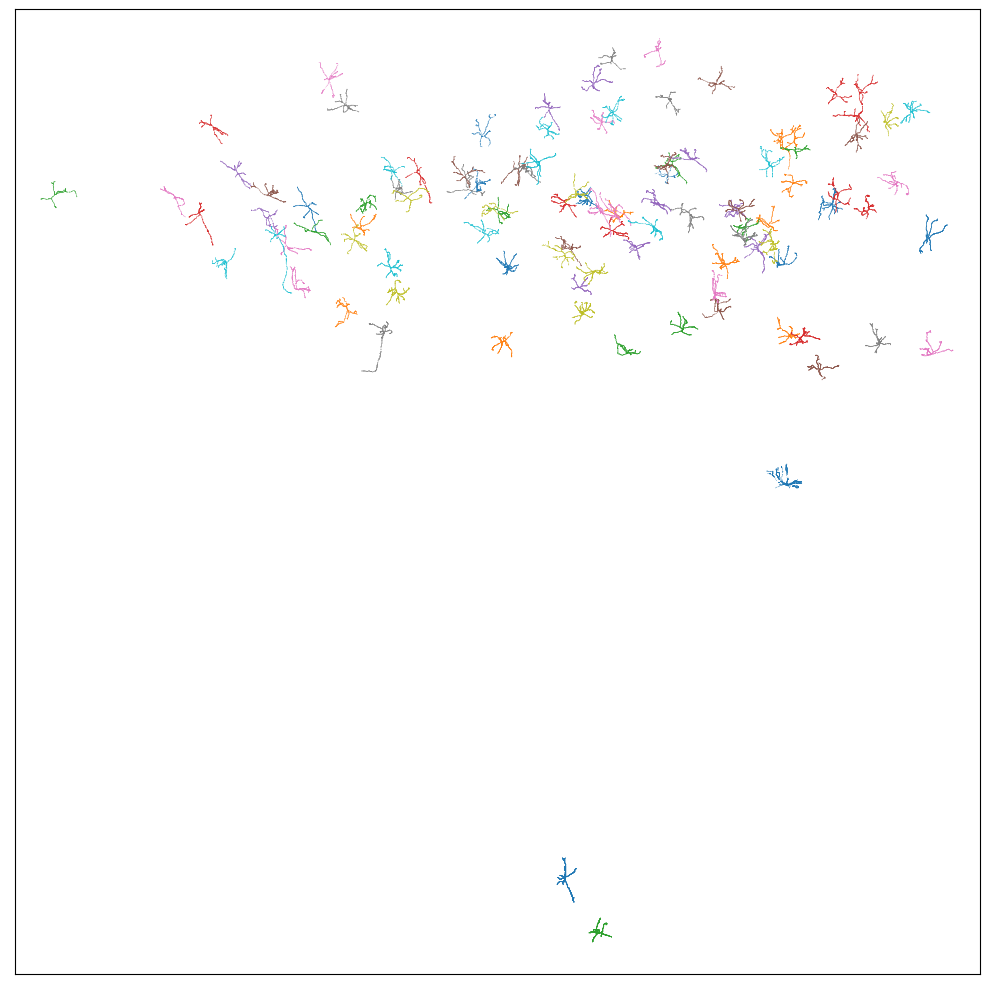

In [65]:
fig = u.create_morphology_scatter_plot(embedding, morphos, files, coords='yz')
# ax.scatter(embedding[:, 0], embedding[:, 1], s=10, c=soma_df["y"], zorder=100)

## unnormalized TSNE

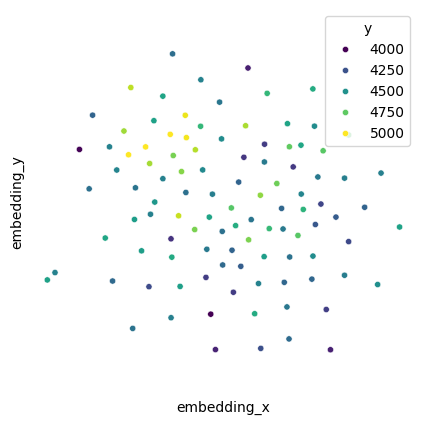

In [66]:
model = manifold.TSNE(n_components=2, metric="precomputed", init="random", random_state=42, perplexity=10)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()


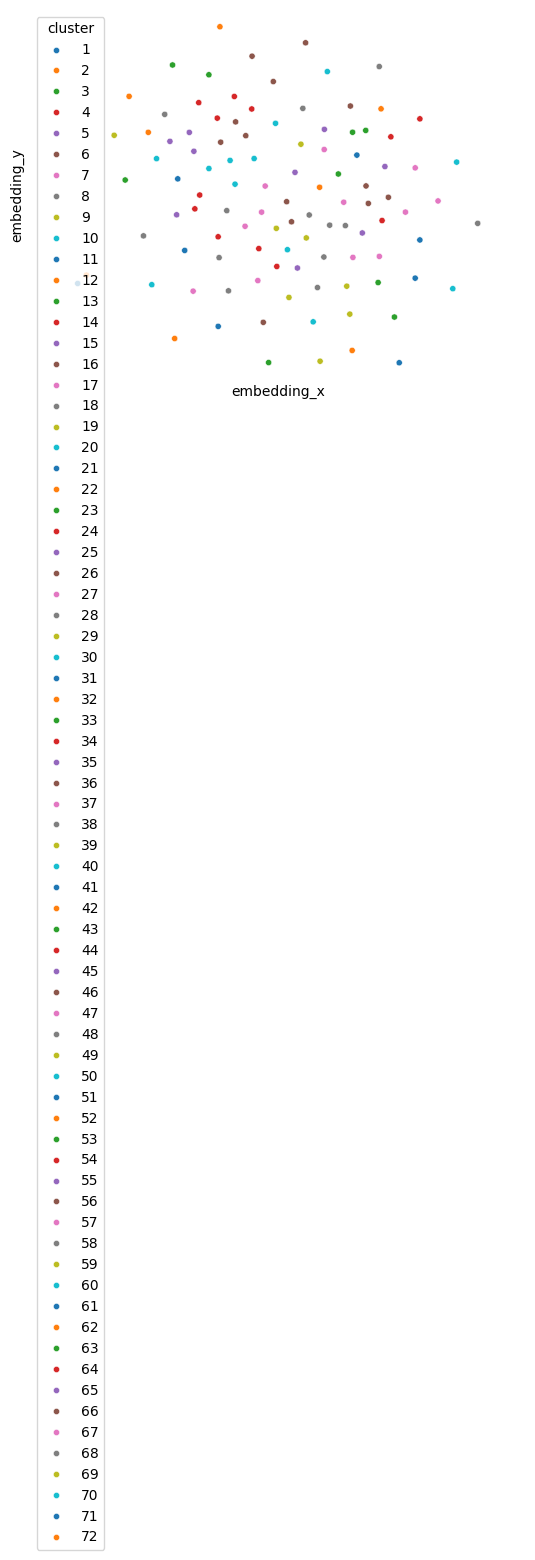

In [67]:

sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="cluster", palette="tab10", s=20, hue_norm=(4000, 5000))
format_plot()

## unnormalized UMAP

/opt/conda/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


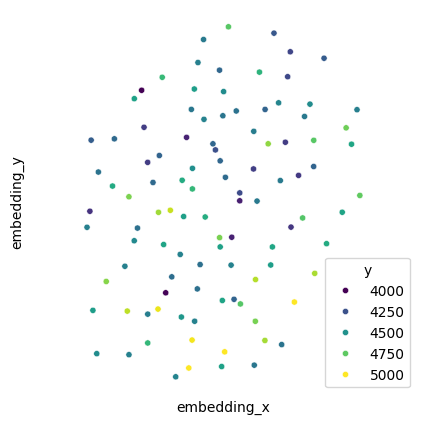

In [68]:
from umap import UMAP
model = UMAP(n_components=2, metric="precomputed", random_state=42, min_dist=1)
embedding = model.fit_transform(distance_matrix_np)
soma_df[["embedding_x", "embedding_y"]] = embedding

plt.figure(figsize=(5, 5))
sns.scatterplot(soma_df, x="embedding_x", y="embedding_y", hue="y", palette="viridis", s=20, hue_norm=(4000, 5000))
format_plot()